# **Validation & Monitoring Pipeline: Cocaine Seizures DB (2025)**

InSight Crime - MAD Unit 

---------------------


In [157]:
import time

start_time = time.time()
formatted_start_time = time.ctime(start_time)
print(f"Start time: {formatted_start_time}")

Start time: Tue Sep 30 11:39:01 2025


## Setup

#### Version Control

The project is created within a single GitHub repository ([FelipeVillota/db-check](https://github.com/FelipeVillota/db-check-cocaine-seizures)). I keep the repository `private` with the possibility to give access to the online repo at any time. 

#### Environment

In [158]:
import os
import subprocess
import sys

# Subprocess Scripting Automation to manage and reproduce Python virtual environment and prepare packages

# Define environment name and path
venv_name = "venv-db-check"
venv_path = os.path.join(os.getcwd(), venv_name)

# 1. Create the virtual environment if it doesn't exist
if not os.path.exists(venv_path):
    # On Linux Mint, ensure python3-venv is installed
    try:
        subprocess.run([sys.executable, "-m", "venv", venv_path], check=True)
        print(f"✅ Created virtual environment: {venv_name}")
    except subprocess.CalledProcessError as e:
        sys.exit(1)
else:
    print(f"✅ Virtual environment '{venv_name}' already exists.")

# 2. Define the venv's python executable (Linux-specific)
venv_python = os.path.join(venv_path, "bin", "python")

# Safety check with more descriptive error
if not os.path.exists(venv_python):
    raise FileNotFoundError(
        f"Python executable not found at {venv_python}"
    )

# 3. Install and upgrade packages
packages = [
    "gspread", "pandas", "requests", "google-api-python-client",
    "oauth2client", "matplotlib", "seaborn", "missingno",
    "gspread-formatting", "ipykernel", "openpyxl", "gspread-dataframe"
]

# Get list of already installed packages
try:
    result = subprocess.run(
        [venv_python, "-m", "pip", "freeze"],
        capture_output=True, text=True, check=True
    )
    installed_packages = result.stdout.lower()
except subprocess.CalledProcessError:
    installed_packages = ""
    print("⚠️ No packages installed yet in virtual environment")

# Check if all required packages are already installed
missing = [pkg for pkg in packages if not any(pkg.lower() in line for line in installed_packages.splitlines())]

if missing:
    print(f"⚠️ Missing packages: {missing}")
    subprocess.run([venv_python, "-m", "pip", "install", "--upgrade", "pip"], check=True)
    subprocess.run([venv_python, "-m", "pip", "install"] + missing, check=True)
    print("✅ Installed missing packages into virtual environment")
else:
    print("✅ All required packages already installed — skipping installation.")

# 4. Register the venv as a Jupyter kernel
kernel_name = "db-check"
display_name = "Python (db-check)"

try:
    subprocess.run([
        venv_python, "-m", "ipykernel", "install", "--user",
        "--name", kernel_name,
        "--display-name", display_name
    ], check=True)
    print(f"✅ Registered Jupyter kernel: {display_name}")
except subprocess.CalledProcessError as e:
    print("Failed to register Jupyter kernel.")
    sys.exit(1)

# 5. Print the Python executable path
print("Python executable:", venv_python)

# 6. Freeze the current package list to requirements.txt
requirements_path = os.path.join(os.getcwd(), "requirements.txt")
with open(requirements_path, "w") as f:
    subprocess.run([venv_python, "-m", "pip", "freeze"], stdout=f, check=True)
print(f"✅ requirements.txt created at {requirements_path}")

✅ Virtual environment 'venv-db-check' already exists.
✅ All required packages already installed — skipping installation.
Installed kernelspec db-check in /home/lfvm/.local/share/jupyter/kernels/db-check
✅ Registered Jupyter kernel: Python (db-check)
Python executable: /home/lfvm/Desktop/codebaker/all_python/db-check/C17H21NO4/2025/venv-db-check/bin/python
✅ requirements.txt created at /home/lfvm/Desktop/codebaker/all_python/db-check/C17H21NO4/2025/requirements.txt


In [159]:
import os
from datetime import datetime

# Get current date
print("Current Date:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

# Count items, files, and directories
items = os.listdir()
files = [f for f in items if os.path.isfile(f)]
directories = [d for d in items if os.path.isdir(d)]

print(f"Total Items: {len(items)}")
print(f"Files: {len(files)}")
print(f"Directories: {len(directories)}")

# Get files sorted by modification time 
print("\nJust files (newest first):")
files_with_mtime = [(f, os.path.getmtime(f)) for f in items if os.path.isfile(f)]
sorted_files = sorted(files_with_mtime, key=lambda x: x[1], reverse=True)

for file, mtime in sorted_files:
    print(f"{datetime.fromtimestamp(mtime)} - {file}")

Current Date: 2025-09-30 11:39:03
Total Items: 9
Files: 5
Directories: 4

Just files (newest first):
2025-09-30 11:39:03.701209 - requirements.txt
2025-09-30 11:37:13.844990 - script.ipynb
2025-09-30 01:16:10.536080 - discrepancies_report.csv
2025-08-31 00:58:04.136420 - reval-db-test.ipynb
2025-08-17 21:30:39.197024 - README.md


#### Libraries

In [160]:
import re
import requests
import pandas as pd
from datetime import datetime
from google.oauth2 import service_account
from googleapiclient.discovery import build
import gspread
from google.oauth2.service_account import Credentials
from gspread_formatting import format_cell_ranges, CellFormat, Color
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import openpyxl as px
import gspread_dataframe as gd

### API

This creates a modular client (frontend) call that is able to extract the desired subset of data from the API server (backend); -and, make it easily reusable for future queries.


In [161]:
# Path to your service account key file
SERVICE_ACCOUNT_FILE = '/home/lfvm/Desktop/codebaker/nyckelring/brelok/summer-sector-439022-v6-2eafffbbfb90.json' # Update with the actual path or team credentials file

# VERY IMPORTANT: Ensure the service account has access to the Google Sheet by sharing it with the service account email

# Original Google Sheet ID (latest version) 
ORIGINAL_SPREADSHEET_ID =  '1t61MafCmnRe2QN082Bk1V0IxBSIW8UUqH1g5mULgb2o'

# Define scopes for Google Sheets and Drive API
SCOPES = ['https://www.googleapis.com/auth/spreadsheets', 
          'https://www.googleapis.com/auth/drive']

In [162]:
# Authenticate and build both Sheets and Drive services
creds = service_account.Credentials.from_service_account_file(
    SERVICE_ACCOUNT_FILE, scopes=SCOPES)
sheet_service = build('sheets', 'v4', credentials=creds)
drive_service = build('drive', 'v3', credentials=creds)

#### First call

In [163]:
# Original spreadsheet
# Last modification: user and time. This information is related to the file itself, not to specific content (sheets, cells, rows)

from googleapiclient.discovery import build
from datetime import datetime
import pytz

def get_last_modifying_user(drive_service, file_id):
    try:
        # Get revisions (only the last one)
        revisions = drive_service.revisions().list(
            fileId=file_id,
            fields="revisions(modifiedTime,lastModifyingUser)"
        ).execute().get('revisions', [])
        
        if not revisions:
            return "No revisions found."
        
        last_revision = revisions[-1]  # Most recent revision
        user_info = last_revision.get('lastModifyingUser', {})
        email = user_info.get('emailAddress', 'Unknown')
        modified_time = last_revision.get('modifiedTime', 'Unknown')
        
        # Convert to readable datetime
        if modified_time != 'Unknown':
            dt = datetime.strptime(modified_time, "%Y-%m-%dT%H:%M:%S.%fZ")
            dt = dt.replace(tzinfo=pytz.UTC)
            modified_time = dt.strftime("%Y-%m-%d %H:%M:%S (UTC)")
        
        return {
            "user_email": email,
            "modified_time": modified_time
        }
    
    except Exception as e:
        return f"Error: {str(e)}"

# Usage
# First get the file name and sheet name
file_metadata = drive_service.files().get(fileId=ORIGINAL_SPREADSHEET_ID, fields='name').execute()
file_name = file_metadata.get('name', 'Unknown')

# Get sheet names
sheets = sheet_service.spreadsheets().get(
    spreadsheetId=ORIGINAL_SPREADSHEET_ID,
    fields='sheets(properties(title))'
).execute().get('sheets', [])

sheet_names = [sheet['properties']['title'] for sheet in sheets]

# Get last modifier info
last_modifier = get_last_modifying_user(drive_service, ORIGINAL_SPREADSHEET_ID)


print(
    f"📄 File name: {file_name}\n"
    f"📑 Sheet names: {', '.join(sheet_names)}\n"
    f"🔄 Last modified by: {last_modifier['user_email']}\n"
    f"⏰ Last modified at: {last_modifier['modified_time']}"
)

📄 File name: incautaciones cocaina 01-02
📑 Sheet names: Codebook, Validation Guide, Guide, Seizures, 2025, 2024, VRAEM, 2023, aligned, Primary Sources, origins, db-test
🔄 Last modified by: db-watch@summer-sector-439022-v6.iam.gserviceaccount.com
⏰ Last modified at: 2025-09-30 09:38:52 (UTC)


## Extraction

Cycle:
* **Dataset A** → raw truth, unformatted, growing, messy. New data appended here by import, manual or automation (*sheet*).

* **Dataset A_aligned** → latest duplicate of truth, intermediate layer, schema-aligned (*sheet + df*).

* **Dataset B** → working copy → initial scenario for formatting, tests, validations and corrections (*sheet + df*).

#### Duplicate

In [164]:
# Function to duplicate an existing sheet and keep it hidden
def duplicate_sheet_hidden(sheet_service, spreadsheet_id, source_sheet_name, new_sheet_name):
    # First get the sheet ID of the source sheet
    spreadsheet = sheet_service.spreadsheets().get(
        spreadsheetId=spreadsheet_id
    ).execute()
    
    # Check if the target sheet already exists
    target_sheet_exists = False
    source_sheet_id = None
    
    for sheet in spreadsheet['sheets']:
        if sheet['properties']['title'] == new_sheet_name:
            target_sheet_exists = True
        if sheet['properties']['title'] == source_sheet_name:
            source_sheet_id = sheet['properties']['sheetId']
    
    if source_sheet_id is None:
        raise ValueError(f"Sheet '{source_sheet_name}' not found")
    
    # If aligned sheet already exists, delete it first
    if target_sheet_exists:
        # Find the sheet ID of the existing target sheet
        target_sheet_id = None
        for sheet in spreadsheet['sheets']:
            if sheet['properties']['title'] == new_sheet_name:
                target_sheet_id = sheet['properties']['sheetId']
                break
        
        if target_sheet_id is not None:
            # Delete the existing sheet
            delete_request = {
                "requests": [
                    {
                        "deleteSheet": {
                            "sheetId": target_sheet_id
                        }
                    }
                ]
            }
            
            sheet_service.spreadsheets().batchUpdate(
                spreadsheetId=spreadsheet_id,
                body=delete_request
            ).execute()
            print(f"Deleted existing sheet '{new_sheet_name}'")
    
    # Create a duplicate of the sheet
    batch_update_request = {
        "requests": [
            {
                "duplicateSheet": {
                    "sourceSheetId": source_sheet_id,
                    "insertSheetIndex": 8,  # Position where to insert the new sheet
                    "newSheetName": new_sheet_name
                }
            }
        ]
    }
    
    # Execute the batch update to duplicate the sheet
    response = sheet_service.spreadsheets().batchUpdate(
        spreadsheetId=spreadsheet_id,
        body=batch_update_request
    ).execute()
    
    # Get the ID of the newly created sheet
    new_sheet_id = response['replies'][0]['duplicateSheet']['properties']['sheetId']
    
    # Update the sheet properties to hide it
    hide_request = {
        "requests": [
            {
                "updateSheetProperties": {
                    "properties": {
                        "sheetId": new_sheet_id,
                        "hidden": True
                    },
                    "fields": "hidden"
                }
            }
        ]
    }
    
    # Execute the batch update to hide the sheet
    sheet_service.spreadsheets().batchUpdate(
        spreadsheetId=spreadsheet_id,
        body=hide_request
    ).execute()
    
    print(f"Duplicated sheet '{source_sheet_name}' to hidden sheet '{new_sheet_name}'")
    return response

# Usage
duplicate_sheet_hidden(sheet_service, ORIGINAL_SPREADSHEET_ID, "2025", "aligned")

Deleted existing sheet 'aligned'
Duplicated sheet '2025' to hidden sheet 'aligned'


{'spreadsheetId': '1t61MafCmnRe2QN082Bk1V0IxBSIW8UUqH1g5mULgb2o',
 'replies': [{'duplicateSheet': {'properties': {'sheetId': 108464312,
     'title': 'aligned',
     'index': 8,
     'sheetType': 'GRID',
     'gridProperties': {'rowCount': 1714,
      'columnCount': 49,
      'frozenRowCount': 1}}}}]}

### Working copy

In the first iteration, the working copy would be a saved version of the first duplicate. Later it's db-test.

### Import as df

In [165]:
# Read data from from two different sheets: aligned & db-test

def get_sheet_data(sheet_service, spreadsheet_id, sheet_name):
    range_name = f"{sheet_name}"  # Add and adjust range if needed 
    result = sheet_service.spreadsheets().values().get(
        spreadsheetId=spreadsheet_id,
        range=range_name
    ).execute()
    values = result.get('values', [])
    if not values:
        return pd.DataFrame()  # Return empty if no data
    return pd.DataFrame(values[1:], columns=values[0])  # Row 0 = headers

# Fetch data 
df_a_aligned = get_sheet_data(sheet_service, ORIGINAL_SPREADSHEET_ID, "aligned")
df_b = get_sheet_data(sheet_service, ORIGINAL_SPREADSHEET_ID, "db-test")

print("\n=== Dataset A_aligned ===")
print(df_a_aligned.info())

print("=== Dataset B ===")
print(df_b.info())


=== Dataset A_aligned ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 919 entries, 0 to 918
Data columns (total 41 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Type                             919 non-null    object
 1   Time unit                        919 non-null    object
 2   Date                             919 non-null    object
 3   Date 2                           919 non-null    object
 4   Year                             919 non-null    object
 5   Month                            919 non-null    object
 6   Day                              919 non-null    object
 7   Duration                         919 non-null    object
 8   Type Drugs                       919 non-null    object
 9   Quantity                         919 non-null    object
 10  Weight unit                      919 non-null    object
 11  Modus Operandi/place of seizure  919 non-null    object
 12  Sub MO   

## Transformation

Normalization processes for the latest duplicate

### Schema to A_aligned

#### Pre-process

In [166]:
# Handle Missing/Invalid Values
 
df_a_aligned = df_a_aligned.replace('', pd.NA)  # Convert empty strings to NA
df_a_aligned = df_a_aligned.replace(r'^\s*$', pd.NA, regex=True)  # Convert whitespace to NA
print("✓ Converted empty strings/whitespace to NA values")

✓ Converted empty strings/whitespace to NA values


#### Column names

In [167]:
custom_column_names = {
    "Type": "event_type",
    "Time unit": "time_unit",
    "Date": "date_1",
    "Date 2": "date_2",
    "Year": "year",
    "Month": "month",
    "Day": "day",
    "Duration": "duration",
    "Type Drugs": "drug_type",
    "Quantity": "quantity",
    "Weight unit": "weight_unit",
    # "seizure_kgs": "seizure_kg", DELETED
    "Modus Operandi/place of seizure": "modus_operandi/place_seizure",
    "Sub MO": "sub_modus_operandi",
    "Region": "region",
    "Country": "country",
    "Department/State": "department/state",
    "Municipality/Port": "municipality/port",
    "Origin country": "origin_country",
    "Origin Area": "origin_area",
    "Origin municipality": "origin_municipality",
    "Transit 1/Region": "transit_1_region",
    "Transit 1/country": "transit_1_country",
    "Transit 1/Department": "transit_1_department/state",
    "Transit 1/Municipality": "transit_1_municipality/port",
    "Transit 2/ region": "transit_2_region",
    "Transit 2/ country": "transit_2_country",
    "Transit 2/Department": "transit_2_department/state",
    "Transit 2/municipality/port": "transit_2_municipality/port",
    "Destition - Region": "destination_1_region",
    "Destition - Country": "destination_1_country",
    "Destition - department.state": "destination_1_department/state",
    "Destition - Municipality/Port": "destination_1_municipality/port",
    "Destition 2 - Country": "destination_2_country",
    "Destition 2 - Municipality/Port": "destination_2_municipality/port",
    "Description": "description",
    "Criminal group #1": "criminal_group_1",
    "Criminal group #2": "criminal_group_2",
    "Criminal group #3": "criminal_group_3",
    "Source link": "source_link",
    "Archived link": "archived_link",
    "Project interested": "project_interested" # Corrected
}

# Apply
df_a_aligned.rename(columns=custom_column_names, inplace=True)


In [168]:
# Get the current headers to map them
current_headers = sheet_service.spreadsheets().values().get(
    spreadsheetId=ORIGINAL_SPREADSHEET_ID,
    range="aligned!1:1",  # Get just header row
    majorDimension="ROWS"
).execute().get('values', [[]])[0]

# Create new headers list by mapping old names to new names
new_headers = [custom_column_names.get(header, header) for header in current_headers]

# Update just the header row
sheet_service.spreadsheets().values().update(
    spreadsheetId=ORIGINAL_SPREADSHEET_ID,
    range="aligned!1:1",  # Update just header row
    valueInputOption='RAW',
    body={'values': [new_headers]}
).execute()

print("Column names updated")

Column names updated


#### Dropdowns


###### Options

In [169]:
# Indentify Existing Dropdowns
 
def get_sheet_dropdowns(spreadsheet_id, sheet_name, creds):
    service = build('sheets', 'v4', credentials=creds)
    sheet_metadata = service.spreadsheets().get(
        spreadsheetId=spreadsheet_id,
        ranges=[sheet_name],
        includeGridData=True
    ).execute()

    dropdowns_by_column = {}

    for sheet in sheet_metadata['sheets']:
        if sheet['properties']['title'] != sheet_name:
            continue

        col_dropdowns = {}
        rows = sheet['data'][0]['rowData']
        header_row = rows[0]['values']
        col_names = [cell.get('formattedValue', f"Column_{i}") for i, cell in enumerate(header_row)]

        for col_idx, col_name in enumerate(col_names):
            dropdowns_in_col = set()
            for row in rows[1:]:  # Skip header
                cell = row['values'][col_idx]
                if 'dataValidation' in cell:
                    dv = cell['dataValidation']
                    if dv['condition']['type'] == 'ONE_OF_LIST':
                        values = [v['userEnteredValue'] for v in dv['condition']['values']]
                        dropdowns_in_col.update(values)
            if dropdowns_in_col:
                col_dropdowns[col_name] = list(dropdowns_in_col)

        dropdowns_by_column.update(col_dropdowns)

    return dropdowns_by_column

dropdown_options = get_sheet_dropdowns(ORIGINAL_SPREADSHEET_ID, "aligned", creds)

# Print results
for col, options in dropdown_options.items():
    print(f"🔽 {col}: {options}")


🔽 event_type: ['Seizure', 'Other (explain in Description)', 'Total Crop Cultivation Estimate', 'Crop Eradication', 'Price', 'Total Production Estimate']
🔽 time_unit: ['Other (explain in Description)', 'Multi-Month', 'Year', 'Multi-Year', 'Individual', 'Month']
🔽 drug_type: ['Other (explain in Description)', 'Cocaine - Crack', 'Cocaine Base', 'Cocaine', 'Coca Crops', 'All/Unspecified/Multiple']
🔽 weight_unit: ['Other (explain in Description)', 'Pounds (£)', 'Other currency (say which in Description)', 'Euro', 'Kilogram', 'Pounds (lbs)', 'Percent', 'Plant', 'Hectare', 'USD', 'Package']
🔽 modus_operandi/place_seizure: ['Container', 'River vessel', 'Land', 'Air', 'Maritime vessel']
🔽 region: ['Europe', 'South America', 'Oceania', 'Global', 'North America', 'Asia', 'Central America', 'Caribbean', 'Africa']
🔽 origin_country: ['""', 'Colombia', 'Peru', 'Bolivia']
🔽 transit_1_region: ['Australia', 'Europe', 'South America', 'Oceania', 'Global', 'North America', 'Asia', 'Central America', 'Cari

In [170]:
dropdown_options = {
    "event_type": [
        'Crop Eradication', 'Total Crop Cultivation Estimate', 'Price',
        'Total Production Estimate', 'Other (explain in Description)', 'Seizure'
    ],
    "time_unit": [
        'Multi-Year', 'Multi-Month', 'Month', 'Other (explain in Description)',
        'Individual', 'Year'
    ],
    "drug_type": [
        'Coca Crops', 'All/Unspecified/Multiple', 'Cocaine',
        'Other (explain in Description)', 'Crack Cocaine', 'Cocaine Base' # UPDATED
    ],
    "weight_unit": [
        'Percent', 'Other currency (say which in Description)', 'Hectare',
        'Euro', 'Plant', 'USD', 'Other (explain in Description)',
        'Pounds (lbs)', 'Kilogram', 'Pounds (£)', 'Package', 'Gram' # ADDED 'Gram'
    ],
    "modus_operandi/place_seizure": [
        'River', 'Maritime', 'Land', 'Air' # UPDATED
    ],
    "sub_modus_operandi": [ # CREATED
        'Other (explain in Description)', 'Backpack/Bag/Suitcase', 'Bicycle', 'Body Carry', 'Bus',
        'Cargo Ship', 'Car', 'Commercial flight', 'Commercial Vessel', 'Container', 'Drone', 'Fishing Vessel', 
        'Go-fast boat', 'Human courier', 'Jetski', 'Mail Shipment', 'Man-powered boat', 'Motorcycle', 
        'Narco-submarine', 'Parcel/Courier Service', 'Passenger ferry', 'Private Boat', 'Private jet', 
        'Sailing Vessel', 'Semi-Submersible', 'Single-prop aircraft', 'Submarine', 'Train', 'Truck', 'Tunneling'
    ],
    "region": [
        'Global', 'Central America', 'Asia', 'Europe', 'Oceania',
        'South America', 'Caribbean', 'North America', 'Africa'
    ],
    "origin_country": ['Peru', 'Bolivia', 'Unknown', 'Colombia'], # '""' REPLACED with 'Unknown'
    
    "transit_1_region": [
        'Global', 'Central America', 'Asia', 'Europe', 'Oceania',
        'South America', 'Caribbean', 'North America', 'Africa'
    ],
    "transit_2_region": [
        'Global', 'Central America', 'Asia', 'Europe', 'Oceania',
        'South America', 'Caribbean', 'North America', 'Africa'
    ],
    "destination_1_region": [
        'Central America', 'Asia', 'Europe', 'South America',
        'Caribbean', 'North America', 'Australia', 'Africa'
    ],
    
    "project_interest": ['Cocaine Pipeline', 'El PACCTO 2.0', 'MAD', 'Dutch']
}

###### Places

In [171]:
# Official list of places URL 
places_url = "https://github.com/FelipeVillota/resources/raw/main/list-of-places-ic.xlsx"

# Load the Excel file (defaulting to first sheet, or specify sheet_name if needed)
places_df = pd.read_excel(places_url)

# Preview the columns to identify the correct one for country list
print(places_df.columns)

print("\nColumns and their unique value counts:")
for col in places_df.columns:
    unique_count = places_df[col].nunique()
    print(f"{col}: {unique_count} unique values")

Index(['municipality', 'department/state', 'country'], dtype='object')

Columns and their unique value counts:
municipality: 129008 unique values
department/state: 3355 unique values
country: 192 unique values


In [172]:
official_countries = (
    places_df["country"]  
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
    .tolist()
)

official_municipalities = (
    places_df["municipality"] 
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
    .tolist()
)

official_departments_states = (
    places_df["department/state"] 
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
    .tolist()
)

In [173]:
country_related_keys = [
    "country",
    "origin_country",
    "transit_1_country",
    "transit_2_country",
    "destination_1_country",
    "destination_2_country"
]

# municipality_related_keys = [
#     "municipality/port",
#     "origin_municipality",
#     "transit_1_municipality/port",
#     "transit_2_municipality/port",
#     "destination_1_municipality/port",
#     "destination_2_municipality/port"
# ]

# department_state_related_keys = [
#     "department/state",
#     # "origin_area",  # assuming this is equivalent
#     "transit_1_department/state",
#     "transit_2_department/state",
#     "destination_1_department/state"
# ]

# Process country-related keys 
for key in country_related_keys:
    dropdown_options[key] = {
        "from_data": sorted(df_a_aligned[key].dropna().astype(str).str.strip().unique().tolist()) if key in df_a_aligned.columns else [],
        "official_list": sorted(official_countries)
    }

# # to municipalities
# for key in municipality_related_keys:
#     dropdown_options[key] = {
#         "from_data": sorted(df[key].dropna().astype(str).str.strip().unique().tolist()) if key in df.columns else [],
#         "official_list": sorted(official_municipalities)
#     }

# # to departments/states
# for key in department_state_related_keys:
#     dropdown_options[key] = {
#         "from_data": sorted(df[key].dropna().astype(str).str.strip().unique().tolist()) if key in df.columns else [],
#         "official_list": sorted(official_departments_states)
#     }


In [174]:
dropdown_options["origin_country"]

{'from_data': ['Bolivia', 'Colombia', 'Peru'],
 'official_list': ['Afghanistan',
  'Albania',
  'Algeria',
  'Andorra',
  'Angola',
  'Antigua And Barbuda',
  'Argentina',
  'Armenia',
  'Australia',
  'Austria',
  'Azerbaijan',
  'Bahamas The',
  'Bahrain',
  'Bangladesh',
  'Barbados',
  'Belarus',
  'Belgium',
  'Belize',
  'Benin',
  'Bhutan',
  'Bolivia',
  'Bosnia and Herzegovina',
  'Botswana',
  'Brazil',
  'Brunei',
  'Bulgaria',
  'Burkina Faso',
  'Burundi',
  'Cambodia',
  'Cameroon',
  'Canada',
  'Cape Verde',
  'Central African Republic',
  'Chad',
  'Chile',
  'China',
  'Colombia',
  'Comoros',
  'Congo',
  'Congo The Democratic Republic Of The',
  'Costa Rica',
  "Cote D'Ivoire (Ivory Coast)",
  'Croatia (Hrvatska)',
  'Cuba',
  'Cyprus',
  'Czech Republic',
  'Denmark',
  'Djibouti',
  'Dominica',
  'Dominican Republic',
  'East Timor',
  'Ecuador',
  'Egypt',
  'El Salvador',
  'Equatorial Guinea',
  'Eritrea',
  'Estonia',
  'Ethiopia',
  'Fiji Islands',
  'Finland

In [175]:
def apply_dropdowns_to_sheet(sheet_service, spreadsheet_id, sheet_name, dropdown_options, max_rows=150000):
    
    # Get the sheet ID by matching the sheet name
    spreadsheet = sheet_service.spreadsheets().get(spreadsheetId=spreadsheet_id).execute()
    sheet_id = None
    for sheet in spreadsheet['sheets']:
        if sheet['properties']['title'] == sheet_name:
            sheet_id = sheet['properties']['sheetId']
            break
    if sheet_id is None:
        print(f"❌ Sheet name '{sheet_name}' not found.")
        return

    # Fetch header row (assumes headers are in row 1)
    result = sheet_service.spreadsheets().values().get(
        spreadsheetId=spreadsheet_id,
        range=f"{sheet_name}!1:1"
    ).execute()
    headers = result.get('values', [])[0]

    requests = []  # Will store all the API requests we need to make

    # Handle both direct list options and dictionary format with "official_list"
    for col_name, options in dropdown_options.items():
        if col_name not in headers:
            continue

        col_index = headers.index(col_name)
        values = (
            options.get("official_list", []) if isinstance(options, dict)
            else options
        )
        values = values[:500]  # Apparently it can only handle this, or else it breaks the API

        if not values:
            continue

    # Create data validation rule for dropdown
        validation_rule = {
            "condition": {
                "type": "ONE_OF_LIST",
                "values": [{"userEnteredValue": str(v)} for v in values]
            },
            "strict": True,
            "showCustomUi": True
        }

    # Add request for this column's dropdown
        requests.append({
            "setDataValidation": {
                "range": {
                    "sheetId": sheet_id,
                    "startRowIndex": 1,
                    "endRowIndex": max_rows,
                    "startColumnIndex": col_index,
                    "endColumnIndex": col_index + 1
                },
                "rule": validation_rule
            }
        })

    # Execute all requests if we have any
    if requests:
        try:
            sheet_service.spreadsheets().batchUpdate(
                spreadsheetId=spreadsheet_id,
                body={"requests": requests}
            ).execute()
            print(f"✅ Applied dropdown formatting to {len(requests)} columns.")
        except Exception as e:
            print(f"❌ Error applying dropdowns: {e}")
    else:
        print("⚠️ No matching columns found in the sheet.")
        
apply_dropdowns_to_sheet(
    sheet_service=sheet_service,
    spreadsheet_id=ORIGINAL_SPREADSHEET_ID,  
    sheet_name="aligned",                 
    dropdown_options=dropdown_options, 
    max_rows=150000                  
)


✅ Applied dropdown formatting to 16 columns.


In [176]:
dropdown_options['sub_modus_operandi']

['Other (explain in Description)',
 'Backpack/Bag/Suitcase',
 'Bicycle',
 'Body Carry',
 'Bus',
 'Cargo Ship',
 'Car',
 'Commercial flight',
 'Commercial Vessel',
 'Container',
 'Drone',
 'Fishing Vessel',
 'Go-fast boat',
 'Human courier',
 'Jetski',
 'Mail Shipment',
 'Man-powered boat',
 'Motorcycle',
 'Narco-submarine',
 'Parcel/Courier Service',
 'Passenger ferry',
 'Private Boat',
 'Private jet',
 'Sailing Vessel',
 'Semi-Submersible',
 'Single-prop aircraft',
 'Submarine',
 'Train',
 'Truck',
 'Tunneling']

#### Number formats

In [177]:
import pandas as pd

def to_numeric_columns(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    """
    Convert specific columns in a DataFrame to numeric dtype.
    """
    df_converted = df.copy()
    for col in cols:
        if col in df_converted.columns:
            df_converted[col] = (
                df_converted[col]
                .astype(str)                  # make sure everything is string
                .str.replace(",", "", regex=False)  # drop thousands separator
                .str.strip()
                .replace("", pd.NA)
            )
            df_converted[col] = pd.to_numeric(df_converted[col], errors="coerce")
            print(f"Column '{col}' converted. dtype={df_converted[col].dtype}")
        else:
            print(f"Warning: '{col}' not found in DataFrame.")
    return df_converted


df_a_aligned = to_numeric_columns(df_a_aligned, ["quantity", "seizure_kg"])



Column 'quantity' converted. dtype=float64


#### Boundaries

Trim blank rows and columns to have the exact db size.

In [178]:
def trim_sheet_to_data(sheet_service, spreadsheet_id, sheet_name):
    """Remove blank rows and columns after the end of actual data in the sheet"""
    
    # Get sheet details without grid data
    spreadsheet = sheet_service.spreadsheets().get(
        spreadsheetId=spreadsheet_id,
        fields="sheets(properties(sheetId,title,gridProperties(rowCount,columnCount)))"
    ).execute()

    sheet_id = None
    total_row_count = 0
    total_col_count = 0
    
    for sheet in spreadsheet["sheets"]:
        if sheet["properties"]["title"] == sheet_name:
            sheet_id = sheet["properties"]["sheetId"]
            total_row_count = sheet["properties"]["gridProperties"]["rowCount"]
            total_col_count = sheet["properties"]["gridProperties"]["columnCount"]
            break

    if sheet_id is None:
        raise ValueError(f"Sheet '{sheet_name}' not found")

    print(f"Scanning sheet '{sheet_name}' for data boundaries...")
    
    # Get all data at once for more efficient column scanning
    try:
        result = sheet_service.spreadsheets().values().get(
            spreadsheetId=spreadsheet_id,
            range=sheet_name,
            majorDimension="ROWS"
        ).execute()
        
        values = result.get('values', [])
        
        if not values:
            print(f"No data found in sheet '{sheet_name}'. No trimming needed.")
            return total_row_count, total_col_count
        
        # Find last row with data
        last_data_row = 0
        for row_idx in range(len(values) - 1, -1, -1):
            row = values[row_idx]
            has_data = any(cell and str(cell).strip() for cell in row)
            if has_data:
                last_data_row = row_idx + 1  # Convert to 1-based index
                break
        
        # Find last column with data
        last_data_col = 0
        # Transpose to scan by columns
        max_cols = max(len(row) for row in values) if values else 0
        for col_idx in range(max_cols - 1, -1, -1):
            has_data = False
            for row in values:
                if col_idx < len(row) and row[col_idx] and str(row[col_idx]).strip():
                    has_data = True
                    break
            if has_data:
                last_data_col = col_idx + 1  # Convert to 1-based index
                break
        
        # Prepare batch update requests
        requests = []
        
        # Delete blank rows if needed
        if last_data_row < total_row_count:
            requests.append({
                "deleteDimension": {
                    "range": {
                        "sheetId": sheet_id,
                        "dimension": "ROWS",
                        "startIndex": last_data_row,
                        "endIndex": total_row_count
                    }
                }
            })
        
        # Delete blank columns if needed
        if last_data_col < total_col_count:
            requests.append({
                "deleteDimension": {
                    "range": {
                        "sheetId": sheet_id,
                        "dimension": "COLUMNS",
                        "startIndex": last_data_col,
                        "endIndex": total_col_count
                    }
                }
            })
        
        # Execute batch update if there are changes
        if requests:
            delete_request = {"requests": requests}
            
            sheet_service.spreadsheets().batchUpdate(
                spreadsheetId=spreadsheet_id,
                body=delete_request
            ).execute()
            
            rows_trimmed = total_row_count - last_data_row if last_data_row < total_row_count else 0
            cols_trimmed = total_col_count - last_data_col if last_data_col < total_col_count else 0
            
            print(f"Trimmed {rows_trimmed} blank rows and {cols_trimmed} blank columns from sheet '{sheet_name}'.")
            print(f"New dimensions: {last_data_row} rows × {last_data_col} columns")
            
            return last_data_row, last_data_col
        else:
            print(f"No blank rows or columns to trim in sheet '{sheet_name}'.")
            return total_row_count, total_col_count
            
    except Exception as e:
        print(f"Error processing sheet '{sheet_name}': {e}")
        return total_row_count, total_col_count


# Usage
trim_sheet_to_data(sheet_service, ORIGINAL_SPREADSHEET_ID, "aligned")

Scanning sheet 'aligned' for data boundaries...
Trimmed 794 blank rows and 8 blank columns from sheet 'aligned'.
New dimensions: 920 rows × 41 columns


(920, 41)

#### Drop blanks

In [179]:
def drop_blank_rows(df: pd.DataFrame) -> pd.DataFrame:
    """
    Drop rows that are entirely blank (all values are NaN or empty string).
    
    Args:
        df: Input DataFrame
    
    Returns:
        DataFrame without blank rows
    """
    df_cleaned = df.replace("", pd.NA).dropna(how="all").reset_index(drop=True)
    return df_cleaned

df_a_aligned = drop_blank_rows(df_a_aligned)


In [180]:
def delete_all_blank_rows(sheet_service, spreadsheet_id, sheet_name):
    """Delete all completely blank rows within the data area of the sheet"""
    
    # Get sheet details
    spreadsheet = sheet_service.spreadsheets().get(
        spreadsheetId=spreadsheet_id,
        fields="sheets(properties(sheetId,title))"
    ).execute()

    sheet_id = None
    for sheet in spreadsheet["sheets"]:
        if sheet["properties"]["title"] == sheet_name:
            sheet_id = sheet["properties"]["sheetId"]
            break

    if sheet_id is None:
        raise ValueError(f"Sheet '{sheet_name}' not found")

    print(f"Scanning sheet '{sheet_name}' for blank rows...")
    
    # Get all data
    try:
        result = sheet_service.spreadsheets().values().get(
            spreadsheetId=spreadsheet_id,
            range=sheet_name,
            majorDimension="ROWS"
        ).execute()
        
        values = result.get('values', [])
        
        if not values:
            print(f"No data found in sheet '{sheet_name}'. No rows to delete.")
            return 0
        
        # Identify blank rows (bottom-up to maintain index integrity)
        blank_row_indices = []
        for row_idx in range(len(values) - 1, -1, -1):
            row = values[row_idx]
            # Check if row is completely empty or has only empty strings
            is_blank = True
            for cell in row:
                if cell and str(cell).strip():
                    is_blank = False
                    break
            
            if is_blank:
                blank_row_indices.append(row_idx)
        
        if not blank_row_indices:
            print(f"No blank rows found in sheet '{sheet_name}'.")
            return 0
        
        # Sort indices in descending order for batch deletion
        blank_row_indices.sort(reverse=True)
        
        # Create batch delete requests (delete rows from bottom to top)
        requests = []
        for row_idx in blank_row_indices:
            requests.append({
                "deleteDimension": {
                    "range": {
                        "sheetId": sheet_id,
                        "dimension": "ROWS",
                        "startIndex": row_idx,
                        "endIndex": row_idx + 1
                    }
                }
            })
        
        # Execute batch deletion
        delete_request = {"requests": requests}
        
        sheet_service.spreadsheets().batchUpdate(
            spreadsheetId=spreadsheet_id,
            body=delete_request
        ).execute()
        
        print(f"Deleted {len(blank_row_indices)} blank rows from sheet '{sheet_name}'.")
        return len(blank_row_indices)
            
    except Exception as e:
        print(f"Error processing sheet '{sheet_name}': {e}")
        return 0
    
delete_all_blank_rows(sheet_service, ORIGINAL_SPREADSHEET_ID, "aligned")

Scanning sheet 'aligned' for blank rows...
No blank rows found in sheet 'aligned'.


0

#### uID

In [181]:
def add_uid_column(sheet_service, spreadsheet_id, sheet_name, uid_col_name="uid"):
    import uuid
    import time
    from googleapiclient.errors import HttpError

    MAX_RETRIES = 3
    RETRY_DELAY = 2  # seconds
    CHUNK_SIZE = 1000

    def execute_with_retry(api_call, *args, **kwargs):
        """Execute API call with retry logic for rate limiting and transient errors"""
        for attempt in range(MAX_RETRIES):
            try:
                return api_call(*args, **kwargs).execute()
            except HttpError as e:
                if e.resp.status in [429, 500, 503]:  # Rate limit or server errors
                    if attempt < MAX_RETRIES - 1:
                        sleep_time = RETRY_DELAY * (2 ** attempt)  # Exponential backoff
                        print(f"Rate limited, retrying in {sleep_time}s (attempt {attempt + 1}/{MAX_RETRIES})")
                        time.sleep(sleep_time)
                        continue
                raise
            except Exception as e:
                if attempt < MAX_RETRIES - 1:
                    print(f"Error occurred, retrying in {RETRY_DELAY}s (attempt {attempt + 1}/{MAX_RETRIES}): {e}")
                    time.sleep(RETRY_DELAY)
                    continue
                raise
        return None

    def column_index_to_a1(column_index):
        """Convert zero-based column index to A1 notation"""
        result = ""
        while column_index >= 0:
            result = chr(65 + (column_index % 26)) + result
            column_index = (column_index // 26) - 1
        return result

    try:
        # Get sheet metadata
        spreadsheet = execute_with_retry(
            sheet_service.spreadsheets().get,
            spreadsheetId=spreadsheet_id,
            fields="sheets(properties(sheetId,title,gridProperties(rowCount,columnCount)))"
        )

        sheet_id = None
        row_count = 0
        original_col_count = 0
        
        for sheet in spreadsheet["sheets"]:
            if sheet["properties"]["title"] == sheet_name:
                sheet_id = sheet["properties"]["sheetId"]
                row_count = sheet["properties"]["gridProperties"]["rowCount"]
                original_col_count = sheet["properties"]["gridProperties"]["columnCount"]
                break

        if sheet_id is None:
            raise ValueError(f"Sheet '{sheet_name}' not found in spreadsheet")

        # Check if UID column already exists
        result = execute_with_retry(
            sheet_service.spreadsheets().values().get,
            spreadsheetId=spreadsheet_id,
            range=f"{sheet_name}!1:1"
        )
        
        values = result.get('values', [])
        headers = values[0] if values else []
        
        # Find existing UID column
        existing_uid_col_index = None
        for i, header in enumerate(headers):
            if header == uid_col_name:
                existing_uid_col_index = i
                break

        # If UID column exists, use it instead of creating a new one
        if existing_uid_col_index is not None:
            print(f"UID column '{uid_col_name}' already exists at column {existing_uid_col_index + 1}")
            insert_col_index = existing_uid_col_index
            col_letter = column_index_to_a1(insert_col_index)
            
            # Clear existing values (keep header)
            clear_range = f"{sheet_name}!{col_letter}2:{col_letter}{row_count}"
            execute_with_retry(
                sheet_service.spreadsheets().values().clear,
                spreadsheetId=spreadsheet_id,
                range=clear_range,
                body={}
            )
        else:
            # Find the last column with data
            last_col_with_data = len(headers) if headers else 0
            
            # If we're at the grid boundary, we need to append rather than insert
            if last_col_with_data >= original_col_count:
                # Append a new column by updating the sheet's grid properties
                append_request = {
                    "updateSheetProperties": {
                        "properties": {
                            "sheetId": sheet_id,
                            "gridProperties": {
                                "columnCount": original_col_count + 1
                            }
                        },
                        "fields": "gridProperties.columnCount"
                    }
                }
                
                execute_with_retry(
                    sheet_service.spreadsheets().batchUpdate,
                    spreadsheetId=spreadsheet_id,
                    body={"requests": [append_request]}
                )
                
                insert_col_index = original_col_count
                col_letter = column_index_to_a1(insert_col_index)
                
                # Set the header for the new column
                header_range = f"{sheet_name}!{col_letter}1"
                execute_with_retry(
                    sheet_service.spreadsheets().values().update,
                    spreadsheetId=spreadsheet_id,
                    range=header_range,
                    valueInputOption="RAW",
                    body={"values": [[uid_col_name]]}
                )
            else:
                # We have room to insert a column
                insert_col_index = last_col_with_data
                col_letter = column_index_to_a1(insert_col_index)

                # Batch requests for inserting column and setting header
                batch_requests = [
                    {
                        "insertDimension": {
                            "range": {
                                "sheetId": sheet_id,
                                "dimension": "COLUMNS",
                                "startIndex": insert_col_index,
                                "endIndex": insert_col_index + 1
                            },
                            "inheritFromBefore": False
                        }
                    },
                    {
                        "updateCells": {
                            "rows": [
                                {"values": [{"userEnteredValue": {"stringValue": uid_col_name}}]}
                            ],
                            "fields": "userEnteredValue",
                            "start": {"sheetId": sheet_id, "rowIndex": 0, "columnIndex": insert_col_index}
                        }
                    }
                ]

                # Execute batch update
                execute_with_retry(
                    sheet_service.spreadsheets().batchUpdate,
                    spreadsheetId=spreadsheet_id,
                    body={"requests": batch_requests}
                )

        # Generate UUIDs and update values in chunks
        if row_count > 1:  # Only if there are data rows
            for start_row in range(1, row_count, CHUNK_SIZE):
                end_row = min(start_row + CHUNK_SIZE, row_count)
                num_rows = end_row - start_row
                
                values = [[str(uuid.uuid4())] for _ in range(num_rows)]
                
                range_uid = f"{sheet_name}!{col_letter}{start_row + 1}:{col_letter}{end_row}"
                
                body = {
                    "valueInputOption": "RAW",
                    "data": [{"range": range_uid, "values": values}]
                }

                execute_with_retry(
                    sheet_service.spreadsheets().values().batchUpdate,
                    spreadsheetId=spreadsheet_id,
                    body=body
                )
                
                # Add a small delay between chunks to avoid rate limiting
                if end_row < row_count:
                    time.sleep(1)

        print(f"UID column '{uid_col_name}' {'updated' if existing_uid_col_index is not None else 'added'} "
              f"in sheet '{sheet_name}' at column {col_letter} ({insert_col_index + 1})")
        
        return insert_col_index, col_letter

    except HttpError as e:
        print(f"Google Sheets API error: {e}")
        raise
    except Exception as e:
        print(f"Unexpected error: {e}")
        raise


# Usage example with comprehensive error handling
try:
    column_index, column_letter = add_uid_column(sheet_service, ORIGINAL_SPREADSHEET_ID, "aligned")
    print(f"Operation completed successfully. UID column at {column_letter} (index {column_index})")
    
except ValueError as e:
    print(f"Configuration error: {e}")
except HttpError as e:
    if e.resp.status == 404:
        print(f"Spreadsheet or sheet not found: {e}")
    elif e.resp.status == 403:
        print(f"Permission denied: {e}")
    else:
        print(f"Google Sheets API error: {e}")
except TimeoutError:
    print("Timeout occurred. Please check your network connection and try again.")
except Exception as e:
    print(f"Unexpected error: {e}")

UID column 'uid' added in sheet 'aligned' at column AP (42)
Operation completed successfully. UID column at AP (index 41)


In [182]:
def copy_uid_column_to_last_column(sheet_service, spreadsheet_id, source_sheet_name, target_sheet_name, uid_col_name="uid"):
    import time
    from googleapiclient.errors import HttpError

    MAX_RETRIES = 3
    RETRY_DELAY = 2  # seconds

    def execute_with_retry(api_call, *args, **kwargs):
        """Execute API call with retry logic for rate limiting and transient errors"""
        for attempt in range(MAX_RETRIES):
            try:
                return api_call(*args, **kwargs).execute()
            except HttpError as e:
                if e.resp.status in [429, 500, 503]:  # Rate limit or server errors
                    if attempt < MAX_RETRIES - 1:
                        sleep_time = RETRY_DELAY * (2 ** attempt)  # Exponential backoff
                        print(f"Rate limited, retrying in {sleep_time}s (attempt {attempt + 1}/{MAX_RETRIES})")
                        time.sleep(sleep_time)
                        continue
                raise
            except Exception as e:
                if attempt < MAX_RETRIES - 1:
                    print(f"Error occurred, retrying in {RETRY_DELAY}s (attempt {attempt + 1}/{MAX_RETRIES}): {e}")
                    time.sleep(RETRY_DELAY)
                    continue
                raise
        return None

    def column_index_to_letter(index):
        """Convert zero-based column index to letter (A, B, C, ...)"""
        result = ""
        while index >= 0:
            result = chr(65 + (index % 26)) + result
            index = (index // 26) - 1
        return result

    try:
        # First, get the UID values from source sheet
        source_values = execute_with_retry(
            sheet_service.spreadsheets().values().get,
            spreadsheetId=spreadsheet_id,
            range=f"{source_sheet_name}"
        )
        
        # Find UID column index in source
        if "values" not in source_values or len(source_values["values"]) == 0:
            raise ValueError(f"No data found in source sheet '{source_sheet_name}'")
        
        source_headers = source_values["values"][0]
        try:
            source_uid_col_index = source_headers.index(uid_col_name)
        except ValueError:
            raise ValueError(f"UID column '{uid_col_name}' not found in source sheet '{source_sheet_name}'")
        
        # Extract UID values (skip header)
        source_uid_values = []
        if len(source_values["values"]) > 1:
            for row in source_values["values"][1:]:
                if len(row) > source_uid_col_index:
                    source_uid_values.append([row[source_uid_col_index]])
                else:
                    source_uid_values.append([""])  # Empty if no UID in this row
        
        # Get target sheet metadata
        spreadsheet = execute_with_retry(
            sheet_service.spreadsheets().get,
            spreadsheetId=spreadsheet_id,
            fields="sheets(properties(sheetId,title,gridProperties(rowCount,columnCount)))"
        )

        target_sheet_id = None
        target_row_count = 0
        target_col_count = 0
        
        for sheet in spreadsheet["sheets"]:
            if sheet["properties"]["title"] == target_sheet_name:
                target_sheet_id = sheet["properties"]["sheetId"]
                target_row_count = sheet["properties"]["gridProperties"]["rowCount"]
                target_col_count = sheet["properties"]["gridProperties"]["columnCount"]
                break

        if target_sheet_id is None:
            raise ValueError(f"Target sheet '{target_sheet_name}' not found in spreadsheet")
        
        # Get target sheet data to check if UID column already exists
        target_values = execute_with_retry(
            sheet_service.spreadsheets().values().get,
            spreadsheetId=spreadsheet_id,
            range=f"{target_sheet_name}"
        )
        
        # Limit UID values to target sheet row count
        uid_values = source_uid_values[:target_row_count - 1] if target_row_count > 1 else []
        
        # Check if UID column already exists in target sheet
        target_uid_col_index = None
        if "values" in target_values and len(target_values["values"]) > 0:
            target_headers = target_values["values"][0]
            try:
                target_uid_col_index = target_headers.index(uid_col_name)
            except ValueError:
                pass  # UID column doesn't exist, will be added to the end
        
        if target_uid_col_index is not None:
            # UID column exists - overwrite values
            target_col_letter = column_index_to_letter(target_uid_col_index)
            
            # Write header (overwrite existing)
            header_range = f"{target_sheet_name}!{target_col_letter}1"
            header_body = {
                "values": [[uid_col_name]]
            }
            execute_with_retry(
                sheet_service.spreadsheets().values().update,
                spreadsheetId=spreadsheet_id,
                range=header_range,
                valueInputOption="RAW",
                body=header_body
            )
            
            # Write UID values (overwrite existing, limited to target row count)
            if uid_values:
                start_row = 2  # Start from row 2 (after header)
                end_row = start_row + len(uid_values) - 1
                
                uid_range = f"{target_sheet_name}!{target_col_letter}{start_row}:{target_col_letter}{end_row}"
                
                body = {
                    "values": uid_values
                }
                
                execute_with_retry(
                    sheet_service.spreadsheets().values().update,
                    spreadsheetId=spreadsheet_id,
                    range=uid_range,
                    valueInputOption="RAW",
                    body=body
                )
            
            print(f"Successfully overwrote {len(uid_values)} UID values in existing column {target_col_letter} in '{target_sheet_name}'")
            
        else:
            # UID column doesn't exist - add to the end
            # Find the last column with data in the target sheet
            last_column_index = 0
            if "values" in target_values and len(target_values["values"]) > 0:
                for row in target_values["values"]:
                    last_column_index = max(last_column_index, len(row) - 1)
            
            # Check if we need to expand the grid
            insert_col_index = last_column_index + 1
            if insert_col_index >= target_col_count:
                # Expand the grid to accommodate the new column
                expand_request = {
                    "updateSheetProperties": {
                        "properties": {
                            "sheetId": target_sheet_id,
                            "gridProperties": {
                                "columnCount": target_col_count + 1
                            }
                        },
                        "fields": "gridProperties.columnCount"
                    }
                }
                
                execute_with_retry(
                    sheet_service.spreadsheets().batchUpdate,
                    spreadsheetId=spreadsheet_id,
                    body={"requests": [expand_request]}
                )
            
            target_col_letter = column_index_to_letter(insert_col_index)
            
            # Write header to the next empty column
            header_range = f"{target_sheet_name}!{target_col_letter}1"
            header_body = {
                "values": [[uid_col_name]]
            }
            execute_with_retry(
                sheet_service.spreadsheets().values().update,
                spreadsheetId=spreadsheet_id,
                range=header_range,
                valueInputOption="RAW",
                body=header_body
            )
            
            # Write UID values to the new column (limited to target row count)
            if uid_values:
                start_row = 2  # Start from row 2 (after header)
                end_row = start_row + len(uid_values) - 1
                
                uid_range = f"{target_sheet_name}!{target_col_letter}{start_row}:{target_col_letter}{end_row}"
                
                body = {
                    "values": uid_values
                }
                
                execute_with_retry(
                    sheet_service.spreadsheets().values().update,
                    spreadsheetId=spreadsheet_id,
                    range=uid_range,
                    valueInputOption="RAW",
                    body=body
                )
            
            print(f"Successfully copied {len(uid_values)} UID values from '{source_sheet_name}' to new column {target_col_letter} in '{target_sheet_name}'")
        
        return len(uid_values)

    except HttpError as e:
        print(f"Google Sheets API error: {e}")
        raise
    except Exception as e:
        print(f"Unexpected error: {e}")
        raise


# Usage example with comprehensive error handling
try:
    copied_count = copy_uid_column_to_last_column(sheet_service, ORIGINAL_SPREADSHEET_ID, "aligned", "db-test")
    print(f"Operation completed successfully. Copied {copied_count} UID values.")
    
except ValueError as e:
    print(f"Configuration error: {e}")
except HttpError as e:
    if e.resp.status == 404:
        print(f"Spreadsheet or sheet not found: {e}")
    elif e.resp.status == 403:
        print(f"Permission denied: {e}")
    else:
        print(f"Google Sheets API error: {e}")
except TimeoutError:
    print("Timeout occurred. Please check your network connection and try again.")
except Exception as e:
    print(f"Unexpected error: {e}")

Successfully overwrote 918 UID values in existing column AP in 'db-test'
Operation completed successfully. Copied 918 UID values.


#### Automations 

In [183]:
# def calculate_seizure_kg(sheet_service, spreadsheet_id, sheet_name="aligned"):
#     import time
#     from googleapiclient.errors import HttpError

#     MAX_RETRIES = 3
#     RETRY_DELAY = 2  # seconds
#     CHUNK_SIZE = 1000

#     def execute_with_retry(api_call, *args, **kwargs):
#         """Execute API call with retry logic for rate limiting and transient errors"""
#         for attempt in range(MAX_RETRIES):
#             try:
#                 return api_call(*args, **kwargs).execute()
#             except HttpError as e:
#                 if e.resp.status in [429, 500, 503]:  # Rate limit or server errors
#                     if attempt < MAX_RETRIES - 1:
#                         sleep_time = RETRY_DELAY * (2 ** attempt)  # Exponential backoff
#                         print(f"Rate limited, retrying in {sleep_time}s (attempt {attempt + 1}/{MAX_RETRIES})")
#                         time.sleep(sleep_time)
#                         continue
#                 raise
#             except Exception as e:
#                 if attempt < MAX_RETRIES - 1:
#                     print(f"Error occurred, retrying in {RETRY_DELAY}s (attempt {attempt + 1}/{MAX_RETRIES}): {e}")
#                     time.sleep(RETRY_DELAY)
#                     continue
#                 raise
#         return None

#     try:
#         # Get all data from the sheet
#         result = execute_with_retry(
#             sheet_service.spreadsheets().values().get,
#             spreadsheetId=spreadsheet_id,
#             range=f"{sheet_name}"
#         )
        
#         values = result.get('values', [])
#         if not values:
#             print(f"No data found in sheet '{sheet_name}'")
#             return 0
        
#         headers = values[0]
        
#         # Find column indices
#         quantity_col_index = None
#         weight_unit_col_index = None
#         seizure_kg_col_index = None
        
#         for i, header in enumerate(headers):
#             if header.lower() == "quantity":
#                 quantity_col_index = i
#             elif header.lower() in ["weight_unit", "weight unit"]:
#                 weight_unit_col_index = i
#             elif header.lower() in ["seizure_kg", "seizure kg"]:
#                 seizure_kg_col_index = i
        
#         if quantity_col_index is None:
#             raise ValueError("'quantity' column not found")
#         if weight_unit_col_index is None:
#             raise ValueError("'weight_unit' column not found")
#         if seizure_kg_col_index is None:
#             raise ValueError("'seizure_kg' column not found")
        
#         # Process data rows and calculate seizure_kg values
#         seizure_kg_updates = []
#         processed_count = 0
        
#         for i, row in enumerate(values[1:], start=2):  # Start from row 2 (skip header)
#             if len(row) <= max(quantity_col_index, weight_unit_col_index, seizure_kg_col_index):
#                 # Skip rows that don't have all required columns
#                 continue
            
#             quantity = row[quantity_col_index].strip() if quantity_col_index < len(row) else ""
#             weight_unit = row[weight_unit_col_index].strip() if weight_unit_col_index < len(row) else ""
            
#             # If weight_unit is "Kilogram", copy quantity to seizure_kg
#             if weight_unit == "Kilogram" and quantity:
#                 seizure_kg_updates.append({
#                     "range": f"{sheet_name}!{chr(65 + seizure_kg_col_index)}{i}",
#                     "values": [[quantity]]
#                 })
#                 processed_count += 1
        
#         # Update seizure_kg values in chunks
#         if seizure_kg_updates:
#             for i in range(0, len(seizure_kg_updates), CHUNK_SIZE):
#                 chunk = seizure_kg_updates[i:i + CHUNK_SIZE]
                
#                 body = {
#                     "valueInputOption": "USER_ENTERED",
#                     "data": chunk
#                 }

#                 execute_with_retry(
#                     sheet_service.spreadsheets().values().batchUpdate,
#                     spreadsheetId=spreadsheet_id,
#                     body=body
#                 )
                
#                 # Add a small delay between chunks to avoid rate limiting
#                 if i + CHUNK_SIZE < len(seizure_kg_updates):
#                     time.sleep(1)

#         print(f"Successfully updated {processed_count} seizure_kg values in sheet '{sheet_name}'")
#         return processed_count

#     except HttpError as e:
#         print(f"Google Sheets API error: {e}")
#         raise
#     except Exception as e:
#         print(f"Unexpected error: {e}")
#         raise


# # Usage example with comprehensive error handling
# try:
#     updated_count = calculate_seizure_kg(sheet_service, ORIGINAL_SPREADSHEET_ID, "aligned")
#     print(f"Operation completed successfully. Updated {updated_count} rows.")
    
# except ValueError as e:
#     print(f"Configuration error: {e}")
# except HttpError as e:
#     if e.resp.status == 404:
#         print(f"Spreadsheet or sheet not found: {e}")
#     elif e.resp.status == 403:
#         print(f"Permission denied: {e}")
#     else:
#         print(f"Google Sheets API error: {e}")
# except TimeoutError:
#     print("Timeout occurred. Please check your network connection and try again.")
# except Exception as e:
#     print(f"Unexpected error: {e}")

In [184]:
# Update after applying schema 
def get_sheet_data(sheet_service, spreadsheet_id, sheet_name):
    range_name = f"{sheet_name}"  # Add and adjust range if needed 
    result = sheet_service.spreadsheets().values().get(
        spreadsheetId=spreadsheet_id,
        range=range_name
    ).execute()
    values = result.get('values', [])
    if not values:
        return pd.DataFrame()  # Return empty if no data
    return pd.DataFrame(values[1:], columns=values[0])  # Row 0 = headers

df_a_aligned = get_sheet_data(sheet_service, ORIGINAL_SPREADSHEET_ID, "aligned")
df_a_aligned = df_a_aligned.replace('', pd.NA)  # Convert empty strings to NA
df_a_aligned = df_a_aligned.replace(r'^\s*$', pd.NA, regex=True)  # Convert whitespace to NA
print("✓ Converted empty strings/whitespace to NA values")

✓ Converted empty strings/whitespace to NA values


In [185]:
def to_numeric_columns(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    """
    Convert specific columns in a DataFrame to numeric dtype.
    """
    df_converted = df.copy()
    for col in cols:
        if col in df_converted.columns:
            df_converted[col] = (
                df_converted[col]
                .astype(str)                  # make sure everything is string
                .str.replace(",", "", regex=False)  # drop thousands separator
                .str.strip()
                .replace("", pd.NA)
            )
            df_converted[col] = pd.to_numeric(df_converted[col], errors="coerce")
            print(f"Column '{col}' converted. dtype={df_converted[col].dtype}")
        else:
            print(f"Warning: '{col}' not found in DataFrame.")
    return df_converted

df_a_aligned = to_numeric_columns(df_a_aligned, ["quantity"])

Column 'quantity' converted. dtype=float64


## Data Sync: Feed Module

The idea is that the sync is logical, preserves row order and maintains schema (formats & sheet sizes).

* Start by appending new rows in A, through A_aligned, in B (by uid).

In [186]:
from googleapiclient.errors import HttpError

def merge_sheets(spreadsheet_id, aligned_sheet_name, db_test_sheet_name):
    try:
        # Get sheet metadata
        spreadsheet = sheet_service.spreadsheets().get(
            spreadsheetId=spreadsheet_id,
            fields="sheets(properties(sheetId,title,gridProperties(rowCount,columnCount)))"
        ).execute()
        
        # Verify both sheets exist and get their properties
        sheet_properties = {}
        for sheet in spreadsheet['sheets']:
            title = sheet['properties']['title']
            if title in [aligned_sheet_name, db_test_sheet_name]:
                sheet_properties[title] = {
                    'id': sheet['properties']['sheetId'],
                    'rowCount': sheet['properties']['gridProperties']['rowCount'],
                    'columnCount': sheet['properties']['gridProperties']['columnCount']
                }
        
        if aligned_sheet_name not in sheet_properties:
            print(f"❌ Sheet '{aligned_sheet_name}' not found")
            return False
        
        if db_test_sheet_name not in sheet_properties:
            print(f"❌ Sheet '{db_test_sheet_name}' not found")
            return False
        
        # Get ALL data from db-test sheet (including empty rows)
        db_test_result = sheet_service.spreadsheets().values().get(
            spreadsheetId=spreadsheet_id,
            range=f"{db_test_sheet_name}",
            majorDimension="ROWS"
        ).execute()
        
        # Get data from aligned sheet
        aligned_result = sheet_service.spreadsheets().values().get(
            spreadsheetId=spreadsheet_id,
            range=f"{aligned_sheet_name}",
            majorDimension="ROWS"
        ).execute()
        
        aligned_values = aligned_result.get('values', [])
        db_test_values = db_test_result.get('values', [])
        
        if not aligned_values:
            print("❌ No data found in aligned sheet")
            return False
        
        if not db_test_values:
            print("❌ No data found in db-test sheet")
            return False
        
        # Verify both sheets have the same headers
        aligned_headers = aligned_values[0]
        db_test_headers = db_test_values[0]
        
        if aligned_headers != db_test_headers:
            print("❌ Headers don't match between sheets")
            print(f"Aligned headers: {aligned_headers}")
            print(f"DB Test headers: {db_test_headers}")
            return False
        
        headers = aligned_headers
        
        # Find UID column index
        try:
            uid_index = headers.index('uid')
        except ValueError:
            print("❌ 'uid' column not found in headers")
            return False
        
        # Create a set of all UIDs in db-test sheet for quick lookup
        existing_uids = set()
        for row in db_test_values[1:]:  # Skip header row
            if len(row) > uid_index and row[uid_index]:
                uid = str(row[uid_index]).strip()
                if uid:
                    existing_uids.add(uid)
        
        # Find new rows in aligned sheet that aren't in db-test
        new_rows = []
        for row in aligned_values[1:]:  # Skip header row
            if len(row) > uid_index and row[uid_index]:
                uid = str(row[uid_index]).strip()
                if uid and uid not in existing_uids:
                    # Pad the row with empty values if it's shorter than headers
                    padded_row = row + [''] * (len(headers) - len(row))
                    new_rows.append(padded_row)
        
        if not new_rows:
            print("✅ No new rows to merge from aligned to db-test")
            return True
        
        # Find the actual last row with data in db-test
        last_row_with_data = 0
        for i, row in enumerate(db_test_values):
            # Check if row has any non-empty cells
            if any(cell and str(cell).strip() for cell in row):
                last_row_with_data = i
        
        # The next available row is right after the last row with data
        append_start_row = last_row_with_data + 1
        
        # Check if we need to expand the db-test sheet
        needed_rows = append_start_row + len(new_rows)
        current_max_rows = sheet_properties[db_test_sheet_name]['rowCount']
        db_test_sheet_id = sheet_properties[db_test_sheet_name]['id']
        
        if needed_rows > current_max_rows:
            print(f"⚠️ Sheet needs expansion: {needed_rows} rows needed, current limit: {current_max_rows}")
            
            # Expand the sheet by exactly the amount needed
            resize_request = {
                'requests': [{
                    'updateSheetProperties': {
                        'properties': {
                            'sheetId': db_test_sheet_id,
                            'gridProperties': {
                                'rowCount': needed_rows,
                                'columnCount': sheet_properties[db_test_sheet_name]['columnCount']
                            }
                        },
                        'fields': 'gridProperties(rowCount,columnCount)'
                    }
                }]
            }
            
            sheet_service.spreadsheets().batchUpdate(
                spreadsheetId=spreadsheet_id,
                body=resize_request
            ).execute()
            
            print(f"✅ Expanded '{db_test_sheet_name}' from {current_max_rows} to {needed_rows} rows")
        
        # Append new rows to db-test sheet starting right after the last row with data
        update_range = f"{db_test_sheet_name}!A{append_start_row + 1}"  # +1 because Sheets is 1-indexed
        
        update_request = {
            'values': new_rows
        }
        
        sheet_service.spreadsheets().values().update(
            spreadsheetId=spreadsheet_id,
            range=update_range,
            valueInputOption='USER_ENTERED',
            body=update_request
        ).execute()
        
        print(f"✅ Successfully appended {len(new_rows)} new rows from '{aligned_sheet_name}' to '{db_test_sheet_name}'")
        print(f"📊 Rows added starting at row: {append_start_row + 1}")
        print(f"📊 Total rows in db-test after merge: {append_start_row + len(new_rows)}")
        
        return True
        
    except HttpError as e:
        if "exceeds grid limits" in str(e):
            print("❌ Error: Cannot add rows - sheet has reached its maximum capacity")
            print("💡 Solution: The sheet expansion might have failed due to Google Sheets limitations")
        else:
            print(f"❌ HTTP Error: {e}")
        return False
    except Exception as e:
        print(f"❌ Error: {e}")
        import traceback
        traceback.print_exc()
        return False

# Call the function
merge_sheets(
    spreadsheet_id=ORIGINAL_SPREADSHEET_ID,
    aligned_sheet_name="aligned",
    db_test_sheet_name="db-test"
)

⚠️ Sheet needs expansion: 920 rows needed, current limit: 919
✅ Expanded 'db-test' from 919 to 920 rows
✅ Successfully appended 1 new rows from 'aligned' to 'db-test'
📊 Rows added starting at row: 920
📊 Total rows in db-test after merge: 920


True

### Remove filters in sheet

In [187]:
from googleapiclient.errors import HttpError

def remove_sheet_filters(spreadsheet_id, sheet_name):
    """
    Remove all filters from a specific sheet in a Google Spreadsheet
    """
    try:
        # Get spreadsheet metadata to find the sheet ID
        spreadsheet = sheet_service.spreadsheets().get(
            spreadsheetId=spreadsheet_id,
            fields="sheets(properties(sheetId,title))"
        ).execute()
        
        # Find the specific sheet ID
        sheet_id = None
        for sheet in spreadsheet['sheets']:
            if sheet['properties']['title'] == sheet_name:
                sheet_id = sheet['properties']['sheetId']
                break
        
        if not sheet_id:
            print(f"Sheet '{sheet_name}' not found")
            return False
        
        # Create request to clear filters
        requests = [{
            'clearBasicFilter': {
                'sheetId': sheet_id
            }
        }]
        
        # Execute the request
        body = {'requests': requests}
        response = sheet_service.spreadsheets().batchUpdate(
            spreadsheetId=spreadsheet_id,
            body=body
        ).execute()
        
        print(f"✅ Successfully removed all filters from '{sheet_name}'")
        return True
        
    except HttpError as error:
        print(f"❌ An HTTP error occurred: {error}")
        return False
    except Exception as error:
        print(f"❌ An error occurred: {error}")
        return False

# Usage
SPREADSHEET_ID = ORIGINAL_SPREADSHEET_ID  
SHEET_NAME = "db-test"  

# Remove filters only
success = remove_sheet_filters(SPREADSHEET_ID, SHEET_NAME)
if success:
    print("Filters removed successfully!")
else:
    print("Failed to remove filters.")

✅ Successfully removed all filters from 'db-test'
Filters removed successfully!


### Schema to B

#### Pre-process

In [188]:
# Handle Missing/Invalid Values
 
df_b = df_b.replace('', pd.NA)  # Convert empty strings to NA
df_b = df_b.replace(r'^\s*$', pd.NA, regex=True)  # Convert whitespace to NA
print("✓ Converted empty strings/whitespace to NA values")

✓ Converted empty strings/whitespace to NA values


#### Column names

In [189]:
custom_column_names = {
    "Type": "event_type",
    "Time unit": "time_unit",
    "Date": "date_1",
    "Date 2": "date_2",
    "Year": "year",
    "Month": "month",
    "Day": "day",
    "Duration": "duration",
    "Type Drugs": "drug_type",
    "Quantity": "quantity",
    "Weight unit": "weight_unit",
    # "seizure_kgs": "seizure_kg", DELETED
    "Modus Operandi/place of seizure": "modus_operandi/place_seizure",
    "Sub MO": "sub_modus_operandi",
    "Region": "region",
    "Country": "country",
    "Department/State": "department/state",
    "Municipality/Port": "municipality/port",
    "Origin country": "origin_country",
    "Origin Area": "origin_area",
    "Origin municipality": "origin_municipality",
    "Transit 1/Region": "transit_1_region",
    "Transit 1/country": "transit_1_country",
    "Transit 1/Department": "transit_1_department/state",
    "Transit 1/Municipality": "transit_1_municipality/port",
    "Transit 2/ region": "transit_2_region",
    "Transit 2/ country": "transit_2_country",
    "Transit 2/Department": "transit_2_department/state",
    "Transit 2/municipality/port": "transit_2_municipality/port",
    "Destition - Region": "destination_1_region",
    "Destition - Country": "destination_1_country",
    "Destition - department.state": "destination_1_department/state",
    "Destition - Municipality/Port": "destination_1_municipality/port",
    "Destition 2 - Country": "destination_2_country",
    "Destition 2 - Municipality/Port": "destination_2_municipality/port",
    "Description": "description",
    "Criminal group #1": "criminal_group_1",
    "Criminal group #2": "criminal_group_2",
    "Criminal group #3": "criminal_group_3",
    "Source link": "source_link",
    "Archived link": "archived_link",
    "Project interested": "project_interested"
}

# Apply
df_a_aligned.rename(columns=custom_column_names, inplace=True)


In [190]:
# Get the current headers to map them
current_headers = sheet_service.spreadsheets().values().get(
    spreadsheetId=ORIGINAL_SPREADSHEET_ID,
    range="db-test!1:1",  # Get just header row
    majorDimension="ROWS"
).execute().get('values', [[]])[0]

# Create new headers list by mapping old names to new names
new_headers = [custom_column_names.get(header, header) for header in current_headers]

# Update just the header row
sheet_service.spreadsheets().values().update(
    spreadsheetId=ORIGINAL_SPREADSHEET_ID,
    range="db-test!1:1",  # Update just header row
    valueInputOption='RAW',
    body={'values': [new_headers]}
).execute()

print("Column names updated")

Column names updated


#### Dropdowns


###### Options

In [191]:
# Indentify Existing Dropdowns
 
def get_sheet_dropdowns(spreadsheet_id, sheet_name, creds):
    service = build('sheets', 'v4', credentials=creds)
    sheet_metadata = service.spreadsheets().get(
        spreadsheetId=spreadsheet_id,
        ranges=[sheet_name],
        includeGridData=True
    ).execute()

    dropdowns_by_column = {}

    for sheet in sheet_metadata['sheets']:
        if sheet['properties']['title'] != sheet_name:
            continue

        col_dropdowns = {}
        rows = sheet['data'][0]['rowData']
        header_row = rows[0]['values']
        col_names = [cell.get('formattedValue', f"Column_{i}") for i, cell in enumerate(header_row)]

        for col_idx, col_name in enumerate(col_names):
            dropdowns_in_col = set()
            for row in rows[1:]:  # Skip header
                cell = row['values'][col_idx]
                if 'dataValidation' in cell:
                    dv = cell['dataValidation']
                    if dv['condition']['type'] == 'ONE_OF_LIST':
                        values = [v['userEnteredValue'] for v in dv['condition']['values']]
                        dropdowns_in_col.update(values)
            if dropdowns_in_col:
                col_dropdowns[col_name] = list(dropdowns_in_col)

        dropdowns_by_column.update(col_dropdowns)

    return dropdowns_by_column

dropdown_options = get_sheet_dropdowns(ORIGINAL_SPREADSHEET_ID, "db-test", creds)

# Print results
for col, options in dropdown_options.items():
    print(f"🔽 {col}: {options}")


🔽 event_type: ['Other (explain in Description)', 'Seizure', 'Crop Eradication', 'Total Crop Cultivation Estimate', 'Price', 'Total Production Estimate']
🔽 time_unit: ['Other (explain in Description)', 'Multi-Month', 'Year', 'Multi-Year', 'Individual', 'Month']
🔽 drug_type: ['Other (explain in Description)', 'Cocaine Base', 'Cocaine', 'Crack Cocaine', 'All/Unspecified/Multiple', 'Coca Crops']
🔽 weight_unit: ['Other (explain in Description)', 'Pounds (£)', 'Other currency (say which in Description)', 'Euro', 'Kilogram', 'Pounds (lbs)', 'Plant', 'Percent', 'Hectare', 'USD', 'Package', 'Gram']
🔽 modus_operandi/place_seizure: ['Land', 'Air', 'Maritime', 'River']
🔽 sub_modus_operandi: ['Other (explain in Description)', 'Fishing Vessel', 'Parcel/Courier Service', 'Bus', 'Train', 'Go-fast boat', 'Cargo Ship', 'Drone', 'Sailing Vessel', 'Commercial flight', 'Private jet', 'Tunneling', 'Semi-Submersible', 'Motorcycle', 'Truck', 'Passenger ferry', 'Commercial Vessel', 'Private Boat', 'Jetski', 'C

In [192]:
dropdown_options = {
    "event_type": [
        'Crop Eradication', 'Total Crop Cultivation Estimate', 'Price',
        'Total Production Estimate', 'Other (explain in Description)', 'Seizure'
    ],
    "time_unit": [
        'Multi-Year', 'Multi-Month', 'Month', 'Other (explain in Description)',
        'Individual', 'Year'
    ],
    "drug_type": [
        'Coca Crops', 'All/Unspecified/Multiple', 'Cocaine',
        'Other (explain in Description)', 'Crack Cocaine', 'Cocaine Base' # UPDATED
    ],
    "weight_unit": [
        'Percent', 'Other currency (say which in Description)', 'Hectare',
        'Euro', 'Plant', 'USD', 'Other (explain in Description)',
        'Pounds (lbs)', 'Kilogram', 'Pounds (£)', 'Package', 'Gram' # ADDED 'Gram'
    ],
    "modus_operandi/place_seizure": [
        'River', 'Maritime', 'Land', 'Air' # UPDATED
    ],
    "sub_modus_operandi": [ # CREATED
        'Other (explain in Description)', 'Backpack/Bag/Suitcase', 'Bicycle', 'Body Carry', 'Bus',
        'Cargo Ship', 'Car', 'Commercial flight', 'Commercial Vessel', 'Container', 'Drone', 'Fishing Vessel', 
        'Go-fast boat', 'Human courier', 'Jetski', 'Mail Shipment', 'Man-powered boat', 'Motorcycle', 
        'Narco-submarine', 'Parcel/Courier Service', 'Passenger ferry', 'Private Boat', 'Private jet', 
        'Sailing Vessel', 'Semi-Submersible', 'Single-prop aircraft', 'Submarine', 'Train', 'Truck', 'Tunneling'
    ],
    "region": [
        'Global', 'Central America', 'Asia', 'Europe', 'Oceania',
        'South America', 'Caribbean', 'North America', 'Africa'
    ],
    "origin_country": ['Peru', 'Bolivia', 'Unknown', 'Colombia'], # '""' REPLACED with 'Unknown'
    
    "transit_1_region": [
        'Global', 'Central America', 'Asia', 'Europe', 'Oceania',
        'South America', 'Caribbean', 'North America', 'Africa'
    ],
    "transit_2_region": [
        'Global', 'Central America', 'Asia', 'Europe', 'Oceania',
        'South America', 'Caribbean', 'North America', 'Africa'
    ],
    "destination_1_region": [
        'Central America', 'Asia', 'Europe', 'South America',
        'Caribbean', 'North America', 'Australia', 'Africa'
    ],
    
    "project_interest": ['Cocaine Pipeline', 'El PACCTO 2.0', 'MAD', 'Dutch']
}

###### Places

In [193]:
# Official list of places URL 
places_url = "https://github.com/FelipeVillota/resources/raw/main/list-of-places-ic.xlsx"

# Load the Excel file (defaulting to first sheet, or specify sheet_name if needed)
places_df = pd.read_excel(places_url)

# Preview the columns to identify the correct one for country list
print(places_df.columns)

print("\nColumns and their unique value counts:")
for col in places_df.columns:
    unique_count = places_df[col].nunique()
    print(f"{col}: {unique_count} unique values")

Index(['municipality', 'department/state', 'country'], dtype='object')

Columns and their unique value counts:
municipality: 129008 unique values
department/state: 3355 unique values
country: 192 unique values


In [194]:
official_countries = (
    places_df["country"]  
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
    .tolist()
)

official_municipalities = (
    places_df["municipality"] 
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
    .tolist()
)

official_departments_states = (
    places_df["department/state"] 
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
    .tolist()
)

In [195]:
country_related_keys = [
    "country",
    "origin_country",
    "transit_1_country",
    "transit_2_country",
    "destination_1_country",
    "destination_2_country"
]

# municipality_related_keys = [
#     "municipality/port",
#     "origin_municipality",
#     "transit_1_municipality/port",
#     "transit_2_municipality/port",
#     "destination_1_municipality/port",
#     "destination_2_municipality/port"
# ]

# department_state_related_keys = [
#     "department/state",
#     # "origin_area",  # assuming this is equivalent
#     "transit_1_department/state",
#     "transit_2_department/state",
#     "destination_1_department/state"
# ]

# Process country-related keys 
for key in country_related_keys:
    dropdown_options[key] = {
        "from_data": sorted(df_b[key].dropna().astype(str).str.strip().unique().tolist()) if key in df_b.columns else [],
        "official_list": sorted(official_countries)
    }

# # to municipalities
# for key in municipality_related_keys:
#     dropdown_options[key] = {
#         "from_data": sorted(df[key].dropna().astype(str).str.strip().unique().tolist()) if key in df.columns else [],
#         "official_list": sorted(official_municipalities)
#     }

# # to departments/states
# for key in department_state_related_keys:
#     dropdown_options[key] = {
#         "from_data": sorted(df[key].dropna().astype(str).str.strip().unique().tolist()) if key in df.columns else [],
#         "official_list": sorted(official_departments_states)
#     }


In [196]:
dropdown_options["origin_country"]

{'from_data': ['Bolivia', 'Colombia', 'Peru'],
 'official_list': ['Afghanistan',
  'Albania',
  'Algeria',
  'Andorra',
  'Angola',
  'Antigua And Barbuda',
  'Argentina',
  'Armenia',
  'Australia',
  'Austria',
  'Azerbaijan',
  'Bahamas The',
  'Bahrain',
  'Bangladesh',
  'Barbados',
  'Belarus',
  'Belgium',
  'Belize',
  'Benin',
  'Bhutan',
  'Bolivia',
  'Bosnia and Herzegovina',
  'Botswana',
  'Brazil',
  'Brunei',
  'Bulgaria',
  'Burkina Faso',
  'Burundi',
  'Cambodia',
  'Cameroon',
  'Canada',
  'Cape Verde',
  'Central African Republic',
  'Chad',
  'Chile',
  'China',
  'Colombia',
  'Comoros',
  'Congo',
  'Congo The Democratic Republic Of The',
  'Costa Rica',
  "Cote D'Ivoire (Ivory Coast)",
  'Croatia (Hrvatska)',
  'Cuba',
  'Cyprus',
  'Czech Republic',
  'Denmark',
  'Djibouti',
  'Dominica',
  'Dominican Republic',
  'East Timor',
  'Ecuador',
  'Egypt',
  'El Salvador',
  'Equatorial Guinea',
  'Eritrea',
  'Estonia',
  'Ethiopia',
  'Fiji Islands',
  'Finland

In [197]:
def apply_dropdowns_to_sheet(sheet_service, spreadsheet_id, sheet_name, dropdown_options, max_rows=150000):
    
    # Get the sheet ID by matching the sheet name
    spreadsheet = sheet_service.spreadsheets().get(spreadsheetId=spreadsheet_id).execute()
    sheet_id = None
    for sheet in spreadsheet['sheets']:
        if sheet['properties']['title'] == sheet_name:
            sheet_id = sheet['properties']['sheetId']
            break
    if sheet_id is None:
        print(f"❌ Sheet name '{sheet_name}' not found.")
        return

    # Fetch header row (assumes headers are in row 1)
    result = sheet_service.spreadsheets().values().get(
        spreadsheetId=spreadsheet_id,
        range=f"{sheet_name}!1:1"
    ).execute()
    headers = result.get('values', [])[0]

    requests = []  # Will store all the API requests we need to make

    # Handle both direct list options and dictionary format with "official_list"
    for col_name, options in dropdown_options.items():
        if col_name not in headers:
            continue

        col_index = headers.index(col_name)
        values = (
            options.get("official_list", []) if isinstance(options, dict)
            else options
        )
        values = values[:500]  # Apparently it can only handle this, or else it breaks the API

        if not values:
            continue

    # Create data validation rule for dropdown
        validation_rule = {
            "condition": {
                "type": "ONE_OF_LIST",
                "values": [{"userEnteredValue": str(v)} for v in values]
            },
            "strict": True,
            "showCustomUi": True
        }

    # Add request for this column's dropdown
        requests.append({
            "setDataValidation": {
                "range": {
                    "sheetId": sheet_id,
                    "startRowIndex": 1,
                    "endRowIndex": max_rows,
                    "startColumnIndex": col_index,
                    "endColumnIndex": col_index + 1
                },
                "rule": validation_rule
            }
        })

    # Execute all requests if we have any
    if requests:
        try:
            sheet_service.spreadsheets().batchUpdate(
                spreadsheetId=spreadsheet_id,
                body={"requests": requests}
            ).execute()
            print(f"✅ Applied dropdown formatting to {len(requests)} columns.")
        except Exception as e:
            print(f"❌ Error applying dropdowns: {e}")
    else:
        print("⚠️ No matching columns found in the sheet.")
        
apply_dropdowns_to_sheet(
    sheet_service=sheet_service,
    spreadsheet_id=ORIGINAL_SPREADSHEET_ID,  
    sheet_name="db-test",                 
    dropdown_options=dropdown_options, 
    max_rows=150000                  
)


✅ Applied dropdown formatting to 16 columns.


#### Number formats

In [198]:
def to_numeric_columns(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    """
    Convert specific columns in a DataFrame to numeric dtype.
    """
    df_converted = df.copy()
    for col in cols:
        if col in df_converted.columns:
            df_converted[col] = (
                df_converted[col]
                .astype(str)                  # make sure everything is string
                .str.replace(",", "", regex=False)  # drop thousands separator
                .str.strip()
                .replace("", pd.NA)
            )
            df_converted[col] = pd.to_numeric(df_converted[col], errors="coerce")
            print(f"Column '{col}' converted. dtype={df_converted[col].dtype}")
        else:
            print(f"Warning: '{col}' not found in DataFrame.")
    return df_converted


df_b = to_numeric_columns(df_b, ["quantity", "seizure_kg"])

Column 'quantity' converted. dtype=float64


#### Drop blanks

In [199]:
def delete_all_blank_rows(sheet_service, spreadsheet_id, sheet_name):
    """Delete all completely blank rows within the data area of the sheet"""
    
    # Get sheet details
    spreadsheet = sheet_service.spreadsheets().get(
        spreadsheetId=spreadsheet_id,
        fields="sheets(properties(sheetId,title))"
    ).execute()

    sheet_id = None
    for sheet in spreadsheet["sheets"]:
        if sheet["properties"]["title"] == sheet_name:
            sheet_id = sheet["properties"]["sheetId"]
            break

    if sheet_id is None:
        raise ValueError(f"Sheet '{sheet_name}' not found")

    print(f"Scanning sheet '{sheet_name}' for blank rows...")
    
    # Get all data
    try:
        result = sheet_service.spreadsheets().values().get(
            spreadsheetId=spreadsheet_id,
            range=sheet_name,
            majorDimension="ROWS"
        ).execute()
        
        values = result.get('values', [])
        
        if not values:
            print(f"No data found in sheet '{sheet_name}'. No rows to delete.")
            return 0
        
        # Identify blank rows (bottom-up to maintain index integrity)
        blank_row_indices = []
        for row_idx in range(len(values) - 1, -1, -1):
            row = values[row_idx]
            # Check if row is completely empty or has only empty strings
            is_blank = True
            for cell in row:
                if cell and str(cell).strip():
                    is_blank = False
                    break
            
            if is_blank:
                blank_row_indices.append(row_idx)
        
        if not blank_row_indices:
            print(f"No blank rows found in sheet '{sheet_name}'.")
            return 0
        
        # Sort indices in descending order for batch deletion
        blank_row_indices.sort(reverse=True)
        
        # Create batch delete requests (delete rows from bottom to top)
        requests = []
        for row_idx in blank_row_indices:
            requests.append({
                "deleteDimension": {
                    "range": {
                        "sheetId": sheet_id,
                        "dimension": "ROWS",
                        "startIndex": row_idx,
                        "endIndex": row_idx + 1
                    }
                }
            })
        
        # Execute batch deletion
        delete_request = {"requests": requests}
        
        sheet_service.spreadsheets().batchUpdate(
            spreadsheetId=spreadsheet_id,
            body=delete_request
        ).execute()
        
        print(f"Deleted {len(blank_row_indices)} blank rows from sheet '{sheet_name}'.")
        return len(blank_row_indices)
            
    except Exception as e:
        print(f"Error processing sheet '{sheet_name}': {e}")
        return 0
    
delete_all_blank_rows(sheet_service, ORIGINAL_SPREADSHEET_ID, "db-test")

Scanning sheet 'db-test' for blank rows...
No blank rows found in sheet 'db-test'.


0

#### Automations 

In [200]:
# def calculate_seizure_kg(sheet_service, spreadsheet_id, sheet_name="db-test"):
#     import time
#     from googleapiclient.errors import HttpError

#     MAX_RETRIES = 3
#     RETRY_DELAY = 2  # seconds
#     CHUNK_SIZE = 1000

#     def execute_with_retry(api_call, *args, **kwargs):
#         """Execute API call with retry logic for rate limiting and transient errors"""
#         for attempt in range(MAX_RETRIES):
#             try:
#                 return api_call(*args, **kwargs).execute()
#             except HttpError as e:
#                 if e.resp.status in [429, 500, 503]:  # Rate limit or server errors
#                     if attempt < MAX_RETRIES - 1:
#                         sleep_time = RETRY_DELAY * (2 ** attempt)  # Exponential backoff
#                         print(f"Rate limited, retrying in {sleep_time}s (attempt {attempt + 1}/{MAX_RETRIES})")
#                         time.sleep(sleep_time)
#                         continue
#                 raise
#             except Exception as e:
#                 if attempt < MAX_RETRIES - 1:
#                     print(f"Error occurred, retrying in {RETRY_DELAY}s (attempt {attempt + 1}/{MAX_RETRIES}): {e}")
#                     time.sleep(RETRY_DELAY)
#                     continue
#                 raise
#         return None

#     try:
#         # Get all data from the sheet
#         result = execute_with_retry(
#             sheet_service.spreadsheets().values().get,
#             spreadsheetId=spreadsheet_id,
#             range=f"{sheet_name}"
#         )
        
#         values = result.get('values', [])
#         if not values:
#             print(f"No data found in sheet '{sheet_name}'")
#             return 0
        
#         headers = values[0]
        
#         # Find column indices
#         quantity_col_index = None
#         weight_unit_col_index = None
#         seizure_kg_col_index = None
        
#         for i, header in enumerate(headers):
#             if header.lower() == "quantity":
#                 quantity_col_index = i
#             elif header.lower() in ["weight_unit", "weight unit"]:
#                 weight_unit_col_index = i
#             elif header.lower() in ["seizure_kg", "seizure kg"]:
#                 seizure_kg_col_index = i
        
#         if quantity_col_index is None:
#             raise ValueError("'quantity' column not found")
#         if weight_unit_col_index is None:
#             raise ValueError("'weight_unit' column not found")
#         if seizure_kg_col_index is None:
#             raise ValueError("'seizure_kg' column not found")
        
#         # Process data rows and calculate seizure_kg values
#         seizure_kg_updates = []
#         processed_count = 0
        
#         for i, row in enumerate(values[1:], start=2):  # Start from row 2 (skip header)
#             if len(row) <= max(quantity_col_index, weight_unit_col_index, seizure_kg_col_index):
#                 # Skip rows that don't have all required columns
#                 continue
            
#             quantity = row[quantity_col_index].strip() if quantity_col_index < len(row) else ""
#             weight_unit = row[weight_unit_col_index].strip() if weight_unit_col_index < len(row) else ""
            
#             # If weight_unit is "Kilogram", copy quantity to seizure_kg
#             if weight_unit == "Kilogram" and quantity:
#                 seizure_kg_updates.append({
#                     "range": f"{sheet_name}!{chr(65 + seizure_kg_col_index)}{i}",
#                     "values": [[quantity]]
#                 })
#                 processed_count += 1
        
#         # Update seizure_kg values in chunks
#         if seizure_kg_updates:
#             for i in range(0, len(seizure_kg_updates), CHUNK_SIZE):
#                 chunk = seizure_kg_updates[i:i + CHUNK_SIZE]
                
#                 body = {
#                     "valueInputOption": "USER_ENTERED",
#                     "data": chunk
#                 }

#                 execute_with_retry(
#                     sheet_service.spreadsheets().values().batchUpdate,
#                     spreadsheetId=spreadsheet_id,
#                     body=body
#                 )
                
#                 # Add a small delay between chunks to avoid rate limiting
#                 if i + CHUNK_SIZE < len(seizure_kg_updates):
#                     time.sleep(1)

#         print(f"Successfully updated {processed_count} seizure_kg values in sheet '{sheet_name}'")
#         return processed_count

#     except HttpError as e:
#         print(f"Google Sheets API error: {e}")
#         raise
#     except Exception as e:
#         print(f"Unexpected error: {e}")
#         raise


# # Usage example with comprehensive error handling
# try:
#     updated_count = calculate_seizure_kg(sheet_service, ORIGINAL_SPREADSHEET_ID, "db-test")
#     print(f"Operation completed successfully. Updated {updated_count} rows.")
    
# except ValueError as e:
#     print(f"Configuration error: {e}")
# except HttpError as e:
#     if e.resp.status == 404:
#         print(f"Spreadsheet or sheet not found: {e}")
#     elif e.resp.status == 403:
#         print(f"Permission denied: {e}")
#     else:
#         print(f"Google Sheets API error: {e}")
# except TimeoutError:
#     print("Timeout occurred. Please check your network connection and try again.")
# except Exception as e:
#     print(f"Unexpected error: {e}")

In [201]:
# Update after applying schema
def get_sheet_data(sheet_service, spreadsheet_id, sheet_name):
    range_name = f"{sheet_name}"  # Add and adjust range if needed 
    result = sheet_service.spreadsheets().values().get(
        spreadsheetId=spreadsheet_id,
        range=range_name
    ).execute()
    values = result.get('values', [])
    if not values:
        return pd.DataFrame()  # Return empty if no data
    return pd.DataFrame(values[1:], columns=values[0])  # Row 0 = headers

# Fetch data 
df_b = get_sheet_data(sheet_service, ORIGINAL_SPREADSHEET_ID, "db-test")
df_b = df_b.replace('', pd.NA)  # Convert empty strings to NA
df_b = df_b.replace(r'^\s*$', pd.NA, regex=True)  # Convert whitespace to NA
print("✓ Converted empty strings/whitespace to NA values")

✓ Converted empty strings/whitespace to NA values


In [202]:
def to_numeric_columns(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    """
    Convert specific columns in a DataFrame to numeric dtype.
    """
    df_converted = df.copy()
    for col in cols:
        if col in df_converted.columns:
            df_converted[col] = (
                df_converted[col]
                .astype(str)                  # make sure everything is string
                .str.replace(",", "", regex=False)  # drop thousands separator
                .str.strip()
                .replace("", pd.NA)
            )
            df_converted[col] = pd.to_numeric(df_converted[col], errors="coerce")
            print(f"Column '{col}' converted. dtype={df_converted[col].dtype}")
        else:
            print(f"Warning: '{col}' not found in DataFrame.")
    return df_converted

df_b = to_numeric_columns(df_b, ["quantity"])

Column 'quantity' converted. dtype=float64


In [203]:
# # Check for problematic values in numeric columns
# for col in ["year", "month", "day", "duration"]:
#     print(f"\nColumn: {col}")
#     print(f"Unique values: {df_b[col].unique()}")
#     print(f"Null values: {df_b[col].isnull().sum()}")

In [204]:
def convert_df_b(df: pd.DataFrame) -> pd.DataFrame:
    """
    Convert df_b columns to appropriate dtypes with robust trash handling.
    - Dates → datetime (errors become NaT)
    - Year: extracts 4-digit years, ignores drug names and text → Int64
    - Month: extracts values 1-12, ignores unrealistic numbers → Int64  
    - Day: extracts values 1-31, ignores measurement units → Int64
    - Duration: extracts numeric values, ignores text descriptions → Int64 or float64
    - Quantities/weights → float64 (errors become NaN)
    - Everything else → string
    - All invalid/trash values become null (NA/NaN/NaT)
    """
    df_converted = df.copy()
    
    # --- Custom cleaning functions ---
    def clean_year(value):
        if pd.isna(value) or not isinstance(value, str):
            return value
        # Extract first 4-digit number found
        import re
        match = re.search(r'\b(19|20)\d{2}\b', str(value))
        return int(match.group()) if match else pd.NA
    
    def clean_month(value):
        if pd.isna(value) or not isinstance(value, str):
            return value
        # Extract first reasonable month number (1-12)
        import re
        match = re.search(r'\b(1[0-2]|[1-9])\b', str(value))
        if match and 1 <= int(match.group()) <= 12:
            return int(match.group())
        return pd.NA
    
    def clean_day(value):
        if pd.isna(value) or not isinstance(value, str):
            return value
        # Extract first reasonable day number (1-31)
        import re
        match = re.search(r'\b(3[01]|[12][0-9]|[1-9])\b', str(value))
        if match and 1 <= int(match.group()) <= 31:
            return int(match.group())
        return pd.NA
    
    def clean_duration(value):
        if pd.isna(value) or not isinstance(value, str):
            return value
        # Extract first numeric value (integer or float)
        import re
        match = re.search(r'\b\d+(\.\d+)?\b', str(value))
        return float(match.group()) if match else pd.NA
    
    # --- Apply specific cleaning ---
    if "year" in df_converted.columns:
        df_converted["year"] = df_converted["year"].apply(clean_year).astype("Int64")
    
    if "month" in df_converted.columns:
        df_converted["month"] = df_converted["month"].apply(clean_month).astype("Int64")
    
    if "day" in df_converted.columns:
        df_converted["day"] = df_converted["day"].apply(clean_day).astype("Int64")
    
    if "duration" in df_converted.columns:
        df_converted["duration"] = df_converted["duration"].apply(clean_duration)
        # Convert to Int64 if all values are integers, otherwise keep as float
        if df_converted["duration"].dropna().apply(float.is_integer).all():
            df_converted["duration"] = df_converted["duration"].astype("Int64")
    
    # --- date columns ---
    for col in ["date_1", "date_2"]:
        if col in df_converted.columns:
            df_converted[col] = pd.to_datetime(df_converted[col], errors="coerce")
    
    # --- numeric continuous ---
    for col in ["quantity", "seizure_kg"]:
        if col in df_converted.columns:
            df_converted[col] = pd.to_numeric(df_converted[col], errors="coerce")
    
    # --- everything else stays as string ---
    for col in df_converted.columns:
        if col not in ["date_1", "date_2", "year", "month", "day", "duration", "quantity", "seizure_kg"]:
            df_converted[col] = df_converted[col].astype("string")
    
    return df_converted

df_b = convert_df_b(df_b)
print(df_b.dtypes)

event_type                         string[python]
time_unit                          string[python]
date_1                             datetime64[ns]
date_2                             datetime64[ns]
year                                        Int64
month                                       Int64
day                                         Int64
duration                                    Int64
drug_type                          string[python]
quantity                                  float64
weight_unit                        string[python]
modus_operandi/place_seizure       string[python]
sub_modus_operandi                 string[python]
region                             string[python]
country                            string[python]
department/state                   string[python]
municipality/port                  string[python]
origin_country                     string[python]
origin_area                        string[python]
origin_municipality                string[python]


In [205]:
# Handle Missing/Invalid Values
 
df_b = df_b.replace('', pd.NA)  # Convert empty strings to NA
df_b = df_b.replace(r'^\s*$', pd.NA, regex=True)  # Convert whitespace to NA
print("✓ Converted empty strings/whitespace to NA values")

✓ Converted empty strings/whitespace to NA values


## Data Sync: Differences & Reconcile

In order to make sure to capture latest changes (e.g., later updates, corrections, mistakes) made in both  A  and B, via A_aligned:

* Rows missing in db-test but present in aligned

* Rows missing in aligned but present in db-test

* Rows with the same UID but different values accross columns

This creates a comparison log to be inspected manually (normally, modifications in B are preferred but it has to be checked). 

In [206]:
import pandas as pd
from googleapiclient.errors import HttpError

def compare_sheets(spreadsheet_id, aligned_sheet_name, db_test_sheet_name):
    try:
        # --- Fetch both sheets ---
        aligned_result = sheet_service.spreadsheets().values().get(
            spreadsheetId=spreadsheet_id,
            range=aligned_sheet_name,
            majorDimension="ROWS"
        ).execute()

        db_test_result = sheet_service.spreadsheets().values().get(
            spreadsheetId=spreadsheet_id,
            range=db_test_sheet_name,
            majorDimension="ROWS"
        ).execute()

        aligned_values = aligned_result.get("values", [])
        db_test_values = db_test_result.get("values", [])

        if not aligned_values or not db_test_values:
            print("❌ One of the sheets is empty.")
            return None

        # --- Headers & sanity checks ---
        aligned_headers = aligned_values[0]
        db_test_headers = db_test_values[0]

        if aligned_headers != db_test_headers:
            print("❌ Headers don't match between sheets")
            print(f"Aligned headers: {aligned_headers}")
            print(f"DB Test headers: {db_test_headers}")
            return None

        headers = aligned_headers

        if "uid" not in headers:
            print("❌ 'uid' column not found")
            return None

        uid_index = headers.index("uid")

        # --- Convert to DataFrames ---
        df_aligned = pd.DataFrame(aligned_values[1:], columns=headers)
        df_dbtest = pd.DataFrame(db_test_values[1:], columns=headers)

        # Strip spaces
        df_aligned = df_aligned.applymap(lambda x: str(x).strip() if pd.notna(x) else x)
        df_dbtest = df_dbtest.applymap(lambda x: str(x).strip() if pd.notna(x) else x)

        # --- Align on UID ---
        aligned_dict = df_aligned.to_dict("records")
        dbtest_dict = df_dbtest.to_dict("records")

        aligned_by_uid = {row["uid"]: (i + 2, row) for i, row in enumerate(aligned_dict)}  # +2 for header offset
        dbtest_by_uid = {row["uid"]: (i + 2, row) for i, row in enumerate(dbtest_dict)}

        discrepancies = []

        # --- Missing in db-test ---
        for uid, (rownum, row) in aligned_by_uid.items():
            if uid not in dbtest_by_uid:
                discrepancies.append({
                    "uid": uid,
                    "issue_type": "missing_in_db_test",
                    "aligned_row": rownum,
                    "db_test_row": None,
                    "column": None,
                    "aligned_value": None,
                    "db_test_value": None
                })

        # --- Missing in aligned ---
        for uid, (rownum, row) in dbtest_by_uid.items():
            if uid not in aligned_by_uid:
                discrepancies.append({
                    "uid": uid,
                    "issue_type": "missing_in_aligned",
                    "aligned_row": None,
                    "db_test_row": rownum,
                    "column": None,
                    "aligned_value": None,
                    "db_test_value": None
                })

        # --- Different values ---
        for uid, (rownum_aligned, row_aligned) in aligned_by_uid.items():
            if uid in dbtest_by_uid:
                rownum_db, row_db = dbtest_by_uid[uid]
                for col in headers:
                    val1 = row_aligned.get(col, "")
                    val2 = row_db.get(col, "")
                    if str(val1).strip() != str(val2).strip():
                        discrepancies.append({
                            "uid": uid,
                            "issue_type": "different_values",
                            "aligned_row": rownum_aligned,
                            "db_test_row": rownum_db,
                            "column": col,
                            "aligned_value": val1,
                            "db_test_value": val2
                        })

        df_discrepancies = pd.DataFrame(discrepancies)
        return df_discrepancies

    except HttpError as e:
        print(f"❌ HTTP Error: {e}")
        return None
    except Exception as e:
        print(f"❌ Error: {e}")
        import traceback
        traceback.print_exc()
        return None


# --- MAIN ---
def main():
    df_discrepancies = compare_sheets(
        spreadsheet_id=ORIGINAL_SPREADSHEET_ID,
        aligned_sheet_name="aligned",
        db_test_sheet_name="db-test"
    )

    if df_discrepancies is None or df_discrepancies.empty:
        print("🎉 Sheets match perfectly! No discrepancies found.")
        return None
    else:
        print(f"⚠️ Found {len(df_discrepancies)} discrepancies.")
        print(df_discrepancies.head())
        return df_discrepancies


if __name__ == "__main__":
    df_discrepancies = main()


⚠️ Found 4121 discrepancies.
                                    uid        issue_type  aligned_row  \
0  d9d3b037-f0cb-499d-be40-cddde2ddc610  different_values            2   
1  d9d3b037-f0cb-499d-be40-cddde2ddc610  different_values            2   
2  3092f6d5-3422-478e-a444-69de7c04cf2f  different_values            3   
3  7eb09de6-23ca-4d62-97ae-6cd783ce7c4d  different_values            4   
4  82680e37-868b-46fe-a404-b4e0bdaa4775  different_values            5   

   db_test_row            column aligned_value      db_test_value  
0            2          quantity            10                10.  
1            2  department/state                          Tuscany  
2            3  department/state                National District  
3            4          quantity          2619             2,619.  
4            5          quantity          1240             1,240.  


/tmp/ipykernel_18138/882095295.py:49: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_aligned = df_aligned.applymap(lambda x: str(x).strip() if pd.notna(x) else x)
/tmp/ipykernel_18138/882095295.py:50: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_dbtest = df_dbtest.applymap(lambda x: str(x).strip() if pd.notna(x) else x)


## Validation

Validation rules are applied always to Dataset B (a.k.a working copy, here db-test)

#### Category mapping

🟥 Event Metadata

🟦 Drugs & Quantities

🟨 Modus Operandi

🟩 Seizure Location

🟫 Origin

🟪 Transit

🟧 Destination

⬛ Criminal Actors

In [207]:
category_mapping = {
    "Event Metadata": [
        "event_type", "time_unit", "date_1", "date_2", "year", "month", "day",
        "duration", "description", "source_link", "project_interested"
    ],
    "Drugs & Quantities": [
        "drug_type", "quantity", "weight_unit"
    ],
    "Modus Operandi": [
        "modus_operandi/place_seizure", "sub_modus_operandi"
    ],
    "Seizure Location": [
        "region", "country", "department/state", "municipality/port"
    ],
    "Origin": [
        "origin_country", "origin_area", "origin_municipality"
    ],
    "Transit": [
        "transit_1_region", "transit_1_country", "transit_1_department/state", "transit_1_municipality/port",
        "transit_2_region", "transit_2_country", "transit_2_department/state", "transit_2_municipality/port"
    ],
    "Destination": [
        "destination_1_region", "destination_1_country", "destination_1_department/state",
        "destination_1_municipality/port", "destination_2_country", "destination_2_municipality/port"
    ],
    "Criminal Actors": [
        "criminal_group_1", "criminal_group_2", "criminal_group_3"
    ]
}

In [208]:
def print_full_mapping(df_b):

    # Create column index mapping
    column_indices = {col: idx for idx, col in enumerate(df_b.columns)}

    # Print header
    print("="*80)
    print("COLUMN MAPPING WITH CATEGORIES AND INDICES".center(80))
    print("="*80)
    print(f"Total columns in DataFrame: {len(df_b.columns)}")
    print(f"Total categories: {len(category_mapping)}\n")

    # Print each category with its columns
    for category, columns in category_mapping.items():
        print(f"\n{category.upper()} (Columns: {len(columns)})")
        print("-"*60)
        
        for col in columns:
            idx = column_indices.get(col, "MISSING")
            non_null = df_b[col].count() if col in df_b.columns else 0
            dtype = df_b[col].dtype if col in df_b.columns else "N/A"
            
            print(f"  {idx:2d} | {col:35} | {str(dtype):10} | Non-null: {non_null:4d}")

    # Print any unmapped columns
    mapped_cols = set().union(*category_mapping.values())
    unmapped_cols = set(df_b.columns) - mapped_cols
    
    if unmapped_cols:
        print("\n⚠️ UNMAPPED COLUMNS:")
        print("-"*60)
        for col in unmapped_cols:
            idx = column_indices[col]
            non_null = df_b[col].count()
            dtype = df_b[col].dtype
            print(f"  {idx:2d} | {col:35} | {str(dtype):10} | Non-null: {non_null:4d}")

    # Print verification summary
    print("\n" + "="*80)
    print("VERIFICATION SUMMARY:")
    print(f"- Mapped columns: {len(mapped_cols & set(df_b.columns))}")
    print(f"- Unmapped columns: {len(unmapped_cols)}")
    print(f"- Missing expected columns: {len(set(mapped_cols) - set(df_b.columns))}")
    print("="*80)


if __name__ == "__main__":
    print_full_mapping(df_b)

                   COLUMN MAPPING WITH CATEGORIES AND INDICES                   
Total columns in DataFrame: 42
Total categories: 8


EVENT METADATA (Columns: 11)
------------------------------------------------------------
   0 | event_type                          | string     | Non-null:  919
   1 | time_unit                           | string     | Non-null:  919
   2 | date_1                              | datetime64[ns] | Non-null:  919
   3 | date_2                              | datetime64[ns] | Non-null:   17
   4 | year                                | Int64      | Non-null:  919
   5 | month                               | Int64      | Non-null:  919
   6 | day                                 | Int64      | Non-null:  919
   7 | duration                            | Int64      | Non-null:   17
  34 | description                         | string     | Non-null:  916
  38 | source_link                         | string     | Non-null:  919
  40 | project_interested             

### Rules

##### Reset fill colors

In [209]:
def reset_background_colors(sheet_service, spreadsheet_id, sheet_name):
    """
    Reset all background colors in the specified Google Sheet to default (no color)
    
    Args:
        sheet_service: Authenticated Google Sheets service object
        spreadsheet_id: ID of the spreadsheet
        sheet_name: Name of the sheet to reset colors
    """
    try:
        # Get the sheet metadata to determine the range
        spreadsheet = sheet_service.spreadsheets().get(
            spreadsheetId=spreadsheet_id
        ).execute()
        
        # Find the sheet ID for the given sheet name
        sheet_id = None
        for sheet in spreadsheet['sheets']:
            if sheet['properties']['title'] == sheet_name:
                sheet_id = sheet['properties']['sheetId']
                break
        
        if sheet_id is None:
            raise ValueError(f"Sheet '{sheet_name}' not found in spreadsheet")
        
        # Get the grid properties to determine the dimensions
        grid_props = None
        for sheet in spreadsheet['sheets']:
            if sheet['properties']['sheetId'] == sheet_id:
                grid_props = sheet['properties']['gridProperties']
                break
        
        if grid_props is None:
            raise ValueError("Could not find grid properties for the sheet")
        
        # Create a batch update request to reset background colors
        requests = [{
            'repeatCell': {
                'range': {
                    'sheetId': sheet_id,
                    'startRowIndex': 0,
                    'endRowIndex': grid_props['rowCount'],
                    'startColumnIndex': 0,
                    'endColumnIndex': grid_props['columnCount']
                },
                'cell': {
                    'userEnteredFormat': {
                        'backgroundColor': {
                            'red': 1.0,
                            'green': 1.0,
                            'blue': 1.0
                        }
                    }
                },
                'fields': 'userEnteredFormat.backgroundColor'
            }
        }]
        
        # Execute the batch update
        body = {
            'requests': requests
        }
        
        result = sheet_service.spreadsheets().batchUpdate(
            spreadsheetId=spreadsheet_id,
            body=body
        ).execute()
        
        print(f"Successfully reset background colors in sheet '{sheet_name}'")
        return result
        
    except Exception as e:
        print(f"Error resetting background colors: {str(e)}")
        raise

# Usage example:
reset_background_colors(
    sheet_service=sheet_service,
    spreadsheet_id=ORIGINAL_SPREADSHEET_ID,
    sheet_name='db-test'
)

Successfully reset background colors in sheet 'db-test'


{'spreadsheetId': '1t61MafCmnRe2QN082Bk1V0IxBSIW8UUqH1g5mULgb2o',
 'replies': [{}]}

##### Event Metadata

Variables: _Type, Time unit, Date, Date 2, Year, Month, Day, Duration, Description, Source link, Project interested_

In [210]:
print(category_mapping["Event Metadata"])

['event_type', 'time_unit', 'date_1', 'date_2', 'year', 'month', 'day', 'duration', 'description', 'source_link', 'project_interested']


In [211]:
def event_metadata_report(df_b):
    
    EVENT_COLS = category_mapping["Event Metadata"]
    report = []
    issues = {}
    total_problems = 0

    # Helper functions
    def to_excel_rows(indices):
        return [i+2 for i in indices]

    def register_issue(name, problematic_df_b, description):
        nonlocal total_problems
        issue_rows = problematic_df_b.index.tolist()
        issues[name] = {
            'indices': issue_rows,
            'excel_rows': to_excel_rows(issue_rows),
            'sample': problematic_df_b,
            'description': description
        }
        count = len(issue_rows)
        total_problems += count
        return count

    # Validation 1: Check for missing critical columns
    missing_cols = [col for col in EVENT_COLS if col not in df_b.columns]
    if missing_cols:
        report.append(("❌ Missing Columns", f"{len(missing_cols)} key columns missing: {', '.join(missing_cols)}"))
        total_problems += len(missing_cols)

    # Validation 2: Date validations
    date_issues = []
    if 'date_1' in df_b.columns:
        empty_dates = df_b[df_b['date_1'].isna()]
        if not empty_dates.empty:
            count = register_issue(
                'empty_primary_dates',
                empty_dates,
                "Rows missing primary date (date_1)"
            )
            date_issues.append(f"{count} empty date_1 values")

    # Validation 3: Duration consistency
    if all(col in df_b.columns for col in ['date_2', 'duration']):
        invalid_duration = df_b[
            (df_b['date_2'].isna()) & 
            (df_b['duration'].notna())
        ]
        if not invalid_duration.empty:
            count = register_issue(
                'duration_without_end_date',
                invalid_duration[['date_1', 'date_2', 'duration']],
                "Has duration but no end date (date_2)"
            )
            date_issues.append(f"{count} duration/date_2 mismatches")

    # Validation 4: Year, Month, Day must not be empty
    date_component_issues = []
    date_components = ['year', 'month', 'day']
    
    for component in date_components:
        if component in df_b.columns:
            empty_components = df_b[df_b[component].isna()]
            if not empty_components.empty:
                count = register_issue(
                    f'empty_{component}',
                    empty_components[[component, 'date_1']],
                    f"Rows missing {component} value"
                )
                date_component_issues.append(f"{count} empty {component} values")
    
    if date_component_issues:
        report.append(("Date Component Issues", "; ".join(date_component_issues)))

    # Validation 5: Time unit logic
    if 'time_unit' in df_b.columns:
        time_unit_issues = []
        
        # Case 1: Multi-day events marked as individual
        if 'date_2' in df_b.columns:
            invalid_time = df_b[
                (df_b['date_2'].notna()) & 
                (df_b['time_unit'] == 'Individual')
            ]
            if not invalid_time.empty:
                count = register_issue(
                    'multiday_individual_events',
                    invalid_time[['time_unit', 'date_1', 'date_2']],
                    "Multi-day event marked as 'Individual' time unit"
                )
                time_unit_issues.append(f"{count} multi-day as Individual")

        # Case 2: Individual events with duration
        if 'duration' in df_b.columns:
            invalid_duration = df_b[
                (df_b['time_unit'] == 'Individual') & 
                (df_b['duration'].notna())
            ]
            if not invalid_duration.empty:
                count = register_issue(
                    'individual_with_duration',
                    invalid_duration[['time_unit', 'duration']],
                    "Individual events shouldn't have duration"
                )
                time_unit_issues.append(f"{count} Individual with duration")

        if time_unit_issues:
            report.append(("Time Unit Issues", "; ".join(time_unit_issues)))

    # Report
    print("="*80)
    print(f"EVENT METADATA VALIDATION REPORT".center(80))
    print(f"Total Issues Found: {total_problems}".center(80))
    print("="*80)
    
    # Summary Section
    print("\nSUMMARY CHECKS:")
    for check, message in report:
        print(f"• {check:<20} {message}")
    
    # Detailed Findings
    if issues:
        print("\n" + "="*80)
        print("DETAILED ISSUES".center(80))
        print("="*80)
        
        for issue_name, data in issues.items():
            print(f"\n❗ {data['description'].upper()}")
            print(f"   Rows affected: {len(data['indices'])} (Spreadsheet rows: {data['excel_rows']})")
            print("\nSample Data:")
            print(data['sample'].head(3).to_string(index=False))
            print("-"*60)
    
    print("\n" + "="*80)
    print("Note: Spreadsheet rows account for header (pandas index + 2)".center(80))
    print("="*80)
    
    return {
        'report': report,
        'issues': issues,
        'total_problems': total_problems
    }

validation_results = event_metadata_report(df_b)

                        EVENT METADATA VALIDATION REPORT                        
                             Total Issues Found: 4                              

SUMMARY CHECKS:
• Time Unit Issues     2 multi-day as Individual; 1 Individual with duration

                                DETAILED ISSUES                                 

❗ HAS DURATION BUT NO END DATE (DATE_2)
   Rows affected: 1 (Spreadsheet rows: [342])

Sample Data:
    date_1 date_2  duration
2025-06-03    NaT        10
------------------------------------------------------------

❗ MULTI-DAY EVENT MARKED AS 'INDIVIDUAL' TIME UNIT
   Rows affected: 2 (Spreadsheet rows: [44, 48])

Sample Data:
 time_unit     date_1     date_2
Individual 2025-04-01 2025-04-01
Individual 2025-04-01 2025-04-01
------------------------------------------------------------

❗ INDIVIDUAL EVENTS SHOULDN'T HAVE DURATION
   Rows affected: 1 (Spreadsheet rows: [48])

Sample Data:
 time_unit  duration
Individual         0
-----------------------

In [212]:
def highlight_category_cells(sheet_service, spreadsheet_id, sheet_name, validation_results, category_name):
    if not validation_results['issues']:
        print("No issues found to highlight")
        return

    # Color: light red
    light_red = {"red": 0.96, "green": 0.8, "blue": 0.8}

    try:
        # Get sheet ID only (no rowData → avoids timeout)
        spreadsheet = sheet_service.spreadsheets().get(
            spreadsheetId=spreadsheet_id,
            fields="sheets(properties(sheetId,title))"
        ).execute()

        sheet_id = None
        for sheet in spreadsheet['sheets']:
            if sheet['properties']['title'] == sheet_name:
                sheet_id = sheet['properties']['sheetId']
                break

        if not sheet_id:
            print(f"Sheet '{sheet_name}' not found")
            return

        # Fetch only the header row via values().get()
        header_row = sheet_service.spreadsheets().values().get(
            spreadsheetId=spreadsheet_id,
            range=f"{sheet_name}!1:1"
        ).execute().get("values", [[]])[0]

        col_indices = {
            header: idx
            for idx, header in enumerate(header_row)
            if header in category_mapping[category_name]
        }

        if not col_indices:
            print(f"Target columns not found in sheet '{sheet_name}'")
            return

        # Prepare format requests
        requests = []
        for issue in validation_results['issues'].values():
            for row in issue['excel_rows']:  # 1-based row numbers
                for col_idx in col_indices.values():
                    requests.append({
                        "repeatCell": {
                            "range": {
                                "sheetId": sheet_id,
                                "startRowIndex": row - 1,
                                "endRowIndex": row,
                                "startColumnIndex": col_idx,
                                "endColumnIndex": col_idx + 1
                            },
                            "cell": {
                                "userEnteredFormat": {
                                    "backgroundColor": light_red
                                }
                            },
                            "fields": "userEnteredFormat.backgroundColor"
                        }
                    })

        # Execute in batches (Google Sheets API limit: 100 requests per batch)
        for i in range(0, len(requests), 100):
            sheet_service.spreadsheets().batchUpdate(
                spreadsheetId=spreadsheet_id,
                body={"requests": requests[i:i+100]}
            ).execute()

        print(f"Highlighted {len(requests)} cells in {len(col_indices)} columns")

    except Exception as e:
        print(f"Error: {str(e)}")


# Usage
highlight_category_cells(
    category_name="Event Metadata",
    sheet_service=sheet_service,
    spreadsheet_id=ORIGINAL_SPREADSHEET_ID,
    sheet_name="db-test",
    validation_results=validation_results
)

Highlighted 44 cells in 11 columns


##### Drugs & Quantities

In [213]:
print(category_mapping["Drugs & Quantities"])

['drug_type', 'quantity', 'weight_unit']


In [214]:
def drugs_and_quantities_report(df_b):
    
    DRUG_COLS = category_mapping["Drugs & Quantities"]
    report = []
    issues = {}
    total_problems = 0

    # Helper function
    def to_excel_rows(indices):
        return [i+2 for i in indices]  # Convert pandas index to spreadsheet rows

    def register_issue(name, problematic_df_b, description):
        nonlocal total_problems
        issue_rows = problematic_df_b.index.tolist()
        issues[name] = {
            'indices': issue_rows,
            'excel_rows': to_excel_rows(issue_rows),
            'sample': problematic_df_b,
            'description': description
        }
        count = len(issue_rows)
        total_problems += count
        return count

    # Convert quantity column to numeric, coercing errors to NaN
    if 'quantity' in df_b.columns:
        df_b = df_b.copy()  # Avoid modifying original
        df_b['quantity_numeric'] = pd.to_numeric(df_b['quantity'], errors='coerce')

    # Validation 1: Drug type validations
    if 'drug_type' in df_b.columns:
        invalid_drugs = df_b[
            df_b['drug_type'].isna() | 
            df_b['drug_type'].str.lower().isin(['', 'unknown', 'n/a', 'na']) |
            ~df_b['drug_type'].str.lower().isin([v.lower() for v in dropdown_options["drug_type"]])
        ]
        if not invalid_drugs.empty:
            count = register_issue(
                'invalid_drug_types',
                invalid_drugs,
                "Missing, invalid, or non-compliant drug type values"
            )
            report.append(("Drug Type Issues", f"{count} invalid drug types"))

    # Validation 2: Quantity validations
    if 'quantity' in df_b.columns:
        # Case 1: Non-numeric quantities
        non_numeric = df_b[df_b['quantity_numeric'].isna()]
        
        # Case 2: Zero/negative quantities (using the numeric version)
        invalid_values = df_b[(df_b['quantity_numeric'].notna()) & (df_b['quantity_numeric'] <= 0)]
        
        qty_issues = pd.concat([non_numeric, invalid_values]).drop_duplicates()
        if not qty_issues.empty:
            count = register_issue(
                'invalid_quantities',
                qty_issues,
                "Non-numeric or zero/negative quantities"
            )
            report.append(("Quantity Issues", f"{count} invalid quantities"))

    # Validation 3: Weight unit validations
    if 'weight_unit' in df_b.columns:
        valid_units = dropdown_options.get('weight_unit', [])
        valid_units_lower = [str(u).lower() for u in valid_units]
        
        invalid_units = df_b[
            df_b['weight_unit'].isna() |
            ~df_b['weight_unit'].astype(str).str.lower().isin(valid_units_lower)
        ]
        
        if not invalid_units.empty:
            count = register_issue(
                'invalid_weight_units',
                invalid_units,
                f"Invalid weight units (valid: {', '.join(valid_units)})"
            )
            report.append(("Weight Unit Issues", f"{count} invalid units"))

    # Validation 4: Seizures in kg - EXCLUDE PACKAGE UNITS (NOT CONSIDERED ISSUES)
    if all(col in df_b.columns for col in ['seizure_kg', 'weight_unit', 'quantity']):
        # Convert seizure_kg to numeric if needed
        df_b['seizure_kg_numeric'] = pd.to_numeric(df_b['seizure_kg'], errors='coerce')
        
        # Exclude Package units from seizure validation (they're not considered issues)
        non_package_rows = df_b[~df_b['weight_unit'].astype(str).str.lower().isin(['package', 'packages', 'pkg'])]
        
        # Case 1: Invalid seizure values (excluding packages)
        invalid_seizure = non_package_rows[
            non_package_rows['seizure_kg_numeric'].isna() | 
            (non_package_rows['seizure_kg_numeric'] < 0)
        ]
        
        # Case 2: Kilogram unit mismatch (excluding packages)
        kg_mismatch = non_package_rows[
            (non_package_rows['weight_unit'].str.lower() == 'kilogram') &
            (non_package_rows['quantity_numeric'].notna()) &
            (non_package_rows['seizure_kg_numeric'].notna()) &
            (non_package_rows['quantity_numeric'] != non_package_rows['seizure_kg_numeric'])
        ]
        
        # Combine issues (excluding packages)
        seizure_issues = pd.concat([invalid_seizure, kg_mismatch]).drop_duplicates()
        if not seizure_issues.empty:
            count = register_issue(
                'seizure_weight_issues',
                seizure_issues,
                "Invalid seizure weights or kilogram mismatches (Package units excluded - not considered issues)"
            )
            report.append(("Seizure Weight Issues", f"{count} problems found"))

    # Generate the report
    print("="*80)
    print(f"DRUGS & QUANTITIES VALIDATION REPORT".center(80))
    print(f"Total Issues Found: {total_problems}".center(80))
    print("="*80)
    
    # Summary Section
    print("\nSUMMARY CHECKS:")
    for check, message in report:
        print(f"• {check:<25} {message}")
    
    # Detailed Findings
    if issues:
        print("\n" + "="*80)
        print("DETAILED ISSUES".center(80))
        print("="*80)
        
        for issue_name, data in issues.items():
            print(f"\n❗ {data['description'].upper()}")
            print(f"   Rows affected: {len(data['indices'])} (Spreadsheet rows: {data['excel_rows']})")
            print("\nSample Data:")
            print(data['sample'].head(3).to_string(index=False))
            print("-"*60)
    
    print("\n" + "="*80)
    print("Note: Spreadsheet rows account for header (pandas index + 2)".center(80))
    print("Note: Package weight units are excluded from seizure validation".center(80))
    print("="*80)
    
    return {
        'report': report,
        'issues': issues,
        'total_problems': total_problems
    }


# Usage
validation_results = drugs_and_quantities_report(df_b)

                      DRUGS & QUANTITIES VALIDATION REPORT                      
                             Total Issues Found: 11                             

SUMMARY CHECKS:
• Drug Type Issues          4 invalid drug types
• Quantity Issues           3 invalid quantities
• Weight Unit Issues        4 invalid units

                                DETAILED ISSUES                                 

❗ MISSING, INVALID, OR NON-COMPLIANT DRUG TYPE VALUES
   Rows affected: 4 (Spreadsheet rows: [85, 107, 126, 393])

Sample Data:
event_type  time_unit     date_1 date_2  year  month  day  duration       drug_type  quantity weight_unit modus_operandi/place_seizure sub_modus_operandi        region country department/state municipality/port origin_country origin_area origin_municipality transit_1_region transit_1_country transit_1_department/state transit_1_municipality/port transit_2_region transit_2_country transit_2_department/state transit_2_municipality/port destination_1_region destinati

In [215]:
def highlight_drugs_quantities_cells(sheet_service, spreadsheet_id, sheet_name, validation_results):
    """
    Highlight cells in 'Drugs & Quantities' columns where validation issues exist.
    Optimized to avoid timeouts by minimizing API calls.
    """
    if not validation_results['issues']:
        print("No issues found to highlight in Drugs & Quantities")
        return
    
    highlight_color = {"red": 0.8, "green": 0.9, "blue": 1.0}

    try:
        # ---- 1. Get sheet ID (fast, no rowData) ----
        spreadsheet = sheet_service.spreadsheets().get(
            spreadsheetId=spreadsheet_id,
            fields="sheets.properties"
        ).execute()

        sheet_id = None
        for s in spreadsheet["sheets"]:
            if s["properties"]["title"] == sheet_name:
                sheet_id = s["properties"]["sheetId"]
                break
        if sheet_id is None:
            print(f"Sheet {sheet_name} not found")
            return

        # ---- 2. Get header row via values API ----
        headers_resp = sheet_service.spreadsheets().values().get(
            spreadsheetId=spreadsheet_id,
            range=f"{sheet_name}!1:1"
        ).execute()
        headers = headers_resp.get("values", [[]])[0]

        # Find target columns from category_mapping
        target_columns = category_mapping["Drugs & Quantities"]
        col_indices = {h: i for i, h in enumerate(headers) if h in target_columns}

        if not col_indices:
            print("Target columns not found in sheet")
            return

        # ---- 3. Build requests (group by row, not cell) ----
        requests = []
        start_col = min(col_indices.values())
        end_col = max(col_indices.values()) + 1

        for issue_data in validation_results['issues'].values():
            for row in issue_data['excel_rows']:  # row numbers are 1-based
                requests.append({
                    "repeatCell": {
                        "range": {
                            "sheetId": sheet_id,
                            "startRowIndex": row - 1,   # zero-based
                            "endRowIndex": row,
                            "startColumnIndex": start_col,
                            "endColumnIndex": end_col
                        },
                        "cell": {
                            "userEnteredFormat": {
                                "backgroundColor": highlight_color
                            }
                        },
                        "fields": "userEnteredFormat.backgroundColor"
                    }
                })

        # ---- 4. Execute in batches (100 per API call) ----
        batch_size = 100
        for i in range(0, len(requests), batch_size):
            sheet_service.spreadsheets().batchUpdate(
                spreadsheetId=spreadsheet_id,
                body={"requests": requests[i:i+batch_size]}
            ).execute()

        print(f"✓ Highlighted {len(requests)} rows across {len(col_indices)} Drugs & Quantities columns")

    except Exception as e:
        print(f"Error highlighting Drugs & Quantities cells: {str(e)}")

validation_results = drugs_and_quantities_report(df_b)

highlight_drugs_quantities_cells(
    sheet_service=sheet_service,
    spreadsheet_id=ORIGINAL_SPREADSHEET_ID,
    sheet_name="db-test",
    validation_results=validation_results
)


                      DRUGS & QUANTITIES VALIDATION REPORT                      
                             Total Issues Found: 11                             

SUMMARY CHECKS:
• Drug Type Issues          4 invalid drug types
• Quantity Issues           3 invalid quantities
• Weight Unit Issues        4 invalid units

                                DETAILED ISSUES                                 

❗ MISSING, INVALID, OR NON-COMPLIANT DRUG TYPE VALUES
   Rows affected: 4 (Spreadsheet rows: [85, 107, 126, 393])

Sample Data:
event_type  time_unit     date_1 date_2  year  month  day  duration       drug_type  quantity weight_unit modus_operandi/place_seizure sub_modus_operandi        region country department/state municipality/port origin_country origin_area origin_municipality transit_1_region transit_1_country transit_1_department/state transit_1_municipality/port transit_2_region transit_2_country transit_2_department/state transit_2_municipality/port destination_1_region destinati

##### Modus Operandi 

Variables: Modus Operandi/place of seizure, Sub MO

In [216]:
def modus_operandi_report(df_b):

    MODUS_COLS = category_mapping["Modus Operandi"]
    report = []
    issues = {}
    total_problems = 0

    # Helper functions (identical to metadata report)
    def to_excel_rows(indices):
        return [i+2 for i in indices]  # For spreadsheet row reference

    def register_issue(name, problematic_df_b, description):
        nonlocal total_problems
        issue_rows = problematic_df_b.index.tolist()
        issues[name] = {
            'indices': issue_rows,
            'excel_rows': to_excel_rows(issue_rows),
            'sample': problematic_df_b[list(set(MODUS_COLS) & set(df_b.columns))],  # Only show relevant cols
            'description': description
        }
        count = len(issue_rows)
        total_problems += count
        return count

    # Validation 1: Missing critical columns
    missing_cols = [col for col in MODUS_COLS if col not in df_b.columns]
    if missing_cols:
        report.append(("❌ Missing Columns", f"{len(missing_cols)} key columns missing: {', '.join(missing_cols)}"))
        total_problems += len(missing_cols)

    # Validation 2: Main Modus Operandi checks
    modus_issues = []
    if 'modus_operandi/place_seizure' in df_b.columns:
        empty_modus = df_b[df_b['modus_operandi/place_seizure'].isna()]
        if not empty_modus.empty:
            count = register_issue(
                'empty_modus_operandi',
                empty_modus,
                "Rows missing modus operandi/place of seizure"
            )
            modus_issues.append(f"{count} empty modus_operandi values")

    # # Validation 3: Sub-Modus validation
    # if 'sub_modus_operandi' in df_b.columns:
    #     orphaned_sub = df_b[
    #         df_b['sub_modus_operandi'].notna() & 
    #         (df_b['modus_operandi/place_seizure'].isna())
    #     ]
    #     if not orphaned_sub.empty:
    #         count = register_issue(
    #             'orphaned_sub_modus',
    #             orphaned_sub[['modus_operandi/place_seizure', 'sub_modus_operandi']],
    #             "Sub-modus operandi exists without main modus"
    #         )
    #         modus_issues.append(f"{count} orphaned sub-modus cases")

    if modus_issues:
        report.append(("Modus Operandi Issues:", "; ".join(modus_issues)))

    # Generate report structure
    print("="*80)
    print(f"MODUS OPERANDI VALIDATION REPORT".center(80))
    print(f"Total Issues Found: {total_problems}".center(80))
    print("="*80)
    
    # Summary Section (identical format)
    print("\nSUMMARY CHECKS:")
    for check, message in report:
        print(f"• {check:<20} {message}")
    
    # Detailed Findings (identical format)
    if issues:
        print("\n" + "="*80)
        print("DETAILED ISSUES".center(80))
        print("="*80)
        
        for issue_name, data in issues.items():
            print(f"\n❗ {data['description'].upper()}")
            print(f"   Rows affected: {len(data['indices'])} (Spreadsheet rows: {data['excel_rows']})")
            print("\nSample Data:")
            print(data['sample'].head(3).to_string(index=False))
            print("-"*60)
    
    print("\n" + "="*80)
    print("Note: Spreadsheet rows account for header (pandas index + 2)".center(80))
    print("="*80)
    
    return {
        'report': report,
        'issues': issues,
        'total_problems': total_problems
    }
    
# Usage 
validation_results = modus_operandi_report(df_b)

                        MODUS OPERANDI VALIDATION REPORT                        
                             Total Issues Found: 1                              

SUMMARY CHECKS:
• Modus Operandi Issues: 1 empty modus_operandi values

                                DETAILED ISSUES                                 

❗ ROWS MISSING MODUS OPERANDI/PLACE OF SEIZURE
   Rows affected: 1 (Spreadsheet rows: [33])

Sample Data:
sub_modus_operandi modus_operandi/place_seizure
              <NA>                         <NA>
------------------------------------------------------------

          Note: Spreadsheet rows account for header (pandas index + 2)          


In [217]:
def format_modus_operandi_cells(sheet_service, spreadsheet_id, sheet_name, validation_results):
    """
    Highlight Modus Operandi cells where validation issues exist.
    Optimized to avoid timeouts by minimizing API calls.
    """
    if not validation_results.get('issues'):
        print("No Modus Operandi cells to highlight")
        return
    
    # Light yellow color
    HIGHLIGHT_COLOR = {"red": 1.0, "green": 1.0, "blue": 0.8}

    try:
        # ---- 1. Get sheetId (fast, no rowData) ----
        spreadsheet = sheet_service.spreadsheets().get(
            spreadsheetId=spreadsheet_id,
            fields="sheets.properties"
        ).execute()

        sheet_id = None
        for s in spreadsheet["sheets"]:
            if s["properties"]["title"] == sheet_name:
                sheet_id = s["properties"]["sheetId"]
                break
        if sheet_id is None:
            print(f"Sheet {sheet_name} not found")
            return

        # ---- 2. Get header row only ----
        headers_resp = sheet_service.spreadsheets().values().get(
            spreadsheetId=spreadsheet_id,
            range=f"{sheet_name}!1:1"
        ).execute()
        headers = headers_resp.get("values", [[]])[0]

        # Map target headers to indices
        target_columns = category_mapping["Modus Operandi"]
        col_indices = {h: i for i, h in enumerate(headers) if h in target_columns}

        if not col_indices:
            print("Modus Operandi columns not found in sheet")
            return

        # ---- 3. Build requests (group per row) ----
        requests = []
        start_col = min(col_indices.values())
        end_col = max(col_indices.values()) + 1

        for issue_data in validation_results['issues'].values():
            for row in issue_data['excel_rows']:  # already 1-based
                requests.append({
                    "repeatCell": {
                        "range": {
                            "sheetId": sheet_id,
                            "startRowIndex": row - 1,
                            "endRowIndex": row,
                            "startColumnIndex": start_col,
                            "endColumnIndex": end_col
                        },
                        "cell": {
                            "userEnteredFormat": {
                                "backgroundColor": HIGHLIGHT_COLOR,
                                "textFormat": {"bold": True}
                            }
                        },
                        "fields": "userEnteredFormat(backgroundColor,textFormat)"
                    }
                })

        # ---- 4. Batch execute (100 per batch) ----
        batch_size = 100
        for i in range(0, len(requests), batch_size):
            sheet_service.spreadsheets().batchUpdate(
                spreadsheetId=spreadsheet_id,
                body={"requests": requests[i:i+batch_size]}
            ).execute()

        print(f"✓ Highlighted {len(requests)} rows across {len(col_indices)} Modus Operandi columns")

    except Exception as e:
        print(f"Error highlighting Modus Operandi cells: {str(e)}")

format_modus_operandi_cells(
    sheet_service=sheet_service,
    spreadsheet_id=ORIGINAL_SPREADSHEET_ID,
    sheet_name="db-test",
    validation_results=validation_results
)


✓ Highlighted 1 rows across 2 Modus Operandi columns


#### Seizure Location

In [218]:
def seizure_location_report(df_b):
    
    SEIZURE_LOCATION_COLS = [
        "region", "country", "department/state", "municipality/port"
    ]
    report = []
    issues = {}
    total_problems = 0

    # Helper functions
    def to_excel_rows(indices):
        return [i+2 for i in indices]

    def register_issue(name, problematic_df_b, description):
        nonlocal total_problems
        issue_rows = problematic_df_b.index.tolist()
        issues[name] = {
            'indices': issue_rows,
            'excel_rows': to_excel_rows(issue_rows),
            'sample': problematic_df_b,
            'description': description
        }
        count = len(issue_rows)
        total_problems += count
        return count

    # Validation 1: Check for missing critical columns
    missing_cols = [col for col in SEIZURE_LOCATION_COLS if col not in df_b.columns]
    if missing_cols:
        report.append(("❌ Missing Columns", f"{len(missing_cols)} key columns missing: {', '.join(missing_cols)}"))
        total_problems += len(missing_cols)

    # Validation 2: No empty cells in any seizure location columns
    location_issues = []
    
    for col in SEIZURE_LOCATION_COLS:
        if col in df_b.columns:
            empty_cells = df_b[df_b[col].isna()]
            if not empty_cells.empty:
                count = register_issue(
                    f'empty_{col}',
                    empty_cells[[col]],
                    f"Rows missing {col} value in seizure location"
                )
                location_issues.append(f"{count} empty {col} values")

    if location_issues:
        report.append(("Location Data Issues", "; ".join(location_issues)))

    # Report
    print("="*80)
    print(f"SEIZURE LOCATION VALIDATION REPORT".center(80))
    print(f"Total Issues Found: {total_problems}".center(80))
    print("="*80)
    
    # Summary Section
    print("\nSUMMARY CHECKS:")
    for check, message in report:
        print(f"• {check:<20} {message}")
    
    # Detailed Findings
    if issues:
        print("\n" + "="*80)
        print("DETAILED ISSUES".center(80))
        print("="*80)
        
        for issue_name, data in issues.items():
            print(f"\n❗ {data['description'].upper()}")
            print(f"   Rows affected: {len(data['indices'])} (Spreadsheet rows: {data['excel_rows']})")
            print("\nSample Data:")
            print(data['sample'].head(3).to_string(index=False))
            print("-"*60)
    
    print("\n" + "="*80)
    print("Note: Spreadsheet rows account for header (pandas index + 2)".center(80))
    print("="*80)
    
    return {
        'report': report,
        'issues': issues,
        'total_problems': total_problems
    }

# Run the validation
seizure_location_results = seizure_location_report(df_b)

                       SEIZURE LOCATION VALIDATION REPORT                       
                            Total Issues Found: 250                             

SUMMARY CHECKS:
• Location Data Issues 7 empty country values; 65 empty department/state values; 178 empty municipality/port values

                                DETAILED ISSUES                                 

❗ ROWS MISSING COUNTRY VALUE IN SEIZURE LOCATION
   Rows affected: 7 (Spreadsheet rows: [171, 210, 337, 525, 711, 781, 918])

Sample Data:
country
   <NA>
   <NA>
   <NA>
------------------------------------------------------------

❗ ROWS MISSING DEPARTMENT/STATE VALUE IN SEIZURE LOCATION
   Rows affected: 65 (Spreadsheet rows: [33, 37, 48, 52, 76, 80, 92, 171, 197, 199, 210, 214, 295, 307, 337, 445, 452, 460, 463, 472, 473, 474, 480, 482, 488, 523, 524, 525, 527, 535, 554, 578, 592, 601, 617, 628, 634, 639, 644, 652, 667, 673, 681, 697, 700, 725, 730, 734, 736, 739, 761, 767, 778, 781, 782, 816, 821, 822, 831, 87

In [219]:
def format_seizure_location_cells(sheet_service, spreadsheet_id, sheet_name, validation_results):
    """
    Highlight Seizure Location cells where validation issues exist.
    Optimized to avoid timeouts by minimizing API calls.
    """
    if not validation_results.get('issues'):
        print("No Seizure Location cells to highlight")
        return
    
    # Light green color for seizure location validation
    HIGHLIGHT_COLOR = {"red": 0.85, "green": 1.0, "blue": 0.85}

    try:
        # ---- 1. Get sheetId (fast, no rowData) ----
        spreadsheet = sheet_service.spreadsheets().get(
            spreadsheetId=spreadsheet_id,
            fields="sheets.properties"
        ).execute()

        sheet_id = None
        for s in spreadsheet["sheets"]:
            if s["properties"]["title"] == sheet_name:
                sheet_id = s["properties"]["sheetId"]
                break
        if sheet_id is None:
            print(f"Sheet {sheet_name} not found")
            return

        # ---- 2. Get header row only ----
        headers_resp = sheet_service.spreadsheets().values().get(
            spreadsheetId=spreadsheet_id,
            range=f"{sheet_name}!1:1"
        ).execute()
        headers = headers_resp.get("values", [[]])[0]

        # Map target headers to indices
        target_columns = ["region", "country", "department/state", "municipality/port"]
        col_indices = {h: i for i, h in enumerate(headers) if h in target_columns}

        if not col_indices:
            print("Seizure Location columns not found in sheet")
            return

        # ---- 3. Build requests (group per row) ----
        requests = []
        start_col = min(col_indices.values())
        end_col = max(col_indices.values()) + 1

        for issue_data in validation_results['issues'].values():
            for row in issue_data['excel_rows']:  # already 1-based
                requests.append({
                    "repeatCell": {
                        "range": {
                            "sheetId": sheet_id,
                            "startRowIndex": row - 1,
                            "endRowIndex": row,
                            "startColumnIndex": start_col,
                            "endColumnIndex": end_col
                        },
                        "cell": {
                            "userEnteredFormat": {
                                "backgroundColor": HIGHLIGHT_COLOR,
                                "textFormat": {"bold": False}
                            }
                        },
                        "fields": "userEnteredFormat(backgroundColor,textFormat)"
                    }
                })

        # ---- 4. Batch execute (100 per batch) ----
        batch_size = 100
        for i in range(0, len(requests), batch_size):
            sheet_service.spreadsheets().batchUpdate(
                spreadsheetId=spreadsheet_id,
                body={"requests": requests[i:i+batch_size]}
            ).execute()

        print(f"✓ Highlighted {len(requests)} rows across {len(col_indices)} Seizure Location columns")

    except Exception as e:
        print(f"Error highlighting Seizure Location cells: {str(e)}")

# Run the highlighting function
format_seizure_location_cells(
    sheet_service=sheet_service,
    spreadsheet_id=ORIGINAL_SPREADSHEET_ID,
    sheet_name="db-test",
    validation_results=seizure_location_results
)

✓ Highlighted 250 rows across 4 Seizure Location columns


In [220]:
max_kg_row= df_b[df_b['weight_unit'] == 'Kilogram'].nlargest(1, 'quantity')
if not max_kg_row.empty:    
    print("Row with maximum quantity in Kilograms:")
    print(max_kg_row.to_string(index=False))

Row with maximum quantity in Kilograms:
event_type   time_unit     date_1     date_2  year  month  day  duration drug_type  quantity weight_unit modus_operandi/place_seizure sub_modus_operandi        region  country department/state municipality/port origin_country origin_area origin_municipality transit_1_region transit_1_country transit_1_department/state transit_1_municipality/port transit_2_region transit_2_country transit_2_department/state transit_2_municipality/port destination_1_region destination_1_country destination_1_department/state destination_1_municipality/port destination_2_country destination_2_municipality/port                                                                                                                                 description criminal_group_1 criminal_group_2 criminal_group_3                                                                                                                                                source_link            archi

## Monitoring

##### Summary Stats

In [221]:
def get_dataframe_summary(df_b):
    
    # --- General DataFrame Info ---
    general_info = {
        "Shape": f"{df_b.shape[0]} rows × {df_b.shape[1]} cols",
        "Memory Usage": f"{df_b.memory_usage(deep=True).sum() / (1024 ** 2):.2f} MB",
        "Columns with NA": f"{df_b.isna().any().sum()} of {len(df_b.columns)}",
        "Duplicate Rows": f"{df_b.duplicated().sum()} ({(df_b.duplicated().mean() * 100):.1f}%)",
        "Numeric Columns": f"{df_b.select_dtypes(include='number').shape[1]}",
        "Categorical Columns": f"{df_b.select_dtypes(include=['object', 'category']).shape[1]}",
        "Datetime Columns": f"{df_b.select_dtypes(include='datetime').shape[1]}"
    }

    # --- Compute dropdown options per column ---
    dropdown_options_dict = {
        col: dropdown_options.get(col, [])
        for col in df_b.columns
    }
    
    # --- Column-Level Stats ---
    column_stats = pd.DataFrame({
        'Variable': df_b.columns,
        'Dtype': df_b.dtypes.values,
        'Unique_Count': df_b.nunique().values,
        'NA_Count': df_b.isna().sum().values,
        'NA_Percentage': (df_b.isna().mean() * 100).round(1).values,
        'Duplicate_Count': df_b.apply(lambda col: col.duplicated(keep=False).sum()).values,
        'Duplicate_Percentage': (df_b.apply(lambda col: col.duplicated(keep=False).mean()) * 100).round(1).values,
        'Unique_Values': df_b.apply(lambda x: x.drop_duplicates().tolist()).values,
        'Dropdown_Options': [dropdown_options_dict[col] for col in df_b.columns],
        'Dropdown_Option_Count': [len(dropdown_options_dict[col]) for col in df_b.columns]
    }).sort_values('Unique_Count', ascending=False)


    # --- Format percentages ---
    column_stats['NA_Percentage'] = column_stats['NA_Percentage'].astype(str) + '%'
    column_stats['Duplicate_Percentage'] = column_stats['Duplicate_Percentage'].astype(str) + '%'

    return general_info, column_stats

# Run the summary
general_info, column_stats = get_dataframe_summary(df_b)

# Print General Info
print("=== GENERAL DATAFRAME INFO ===")
for key, value in general_info.items():
    print(f"{key}: {value}")

# Display Column Stats (including dropdown options)
print("\n=== COLUMN-LEVEL STATISTICS ===")
display(column_stats)


=== GENERAL DATAFRAME INFO ===
Shape: 919 rows × 42 cols
Memory Usage: 2.18 MB
Columns with NA: 31 of 42
Duplicate Rows: 0 (0.0%)
Numeric Columns: 5
Categorical Columns: 0
Datetime Columns: 2

=== COLUMN-LEVEL STATISTICS ===


,Variable,Dtype,Unique_Count,NA_Count,NA_Percentage,Duplicate_Count,Duplicate_Percentage,Unique_Values,Dropdown_Options,Dropdown_Option_Count
41,uid,string[python],919,0,0.0%,0,0.0%,"[d9d3b037-f0cb-499d-be40-cddde2ddc610, 3092f6d...",[],0
34,description,string[python],906,3,0.3%,23,2.5%,"[Spanish citizen, coming from Lisbon , was sto...",[],0
38,source_link,string[python],868,0,0.0%,98,10.7%,[https://www.lanazione.it/firenze/cronaca/coca...,[],0
16,municipality/port,string[python],572,178,19.4%,438,47.7%,"[Florence, Santo Domingo, Lake Maracaibo , Eag...",[],0
9,quantity,float64,518,3,0.3%,553,60.2%,"[10.0, 2.5, 2619.0, 1240.0, 16.05, 65.0, 6600....",[],0
15,department/state,string[python],387,65,7.1%,674,73.3%,"[Tuscany, National District, Zulia, Texas, Các...",[],0
12,sub_modus_operandi,string[python],291,617,67.1%,638,69.4%,"[Liquid cocaine, <NA>, Production laboratory, ...","[Other (explain in Description), Backpack/Bag/...",30
2,date_1,datetime64[ns],191,0,0.0%,892,97.1%,"[2025-03-24 00:00:00, 2025-03-23 00:00:00, 202...",[],0
23,transit_1_municipality/port,string[python],168,708,77.0%,780,84.9%,"[<NA>, Matapalo, Rio de Janeiro, Acapulco, Kin...",[],0
22,transit_1_department/state,string[python],127,682,74.2%,827,90.0%,"[Lisbon, <NA>, Santo Domingo, Paris, Puntarena...",[],0


##### Missing Data


Missing values per column:
event_type                           0
time_unit                            0
date_1                               0
date_2                             902
year                                 0
month                                0
day                                  0
duration                           902
drug_type                            0
quantity                             3
weight_unit                          2
modus_operandi/place_seizure         1
sub_modus_operandi                 617
region                               0
country                              7
department/state                    65
municipality/port                  178
origin_country                     802
origin_area                        875
origin_municipality                890
transit_1_region                   559
transit_1_country                  541
transit_1_department/state         682
transit_1_municipality/port        708
transit_2_region                   85

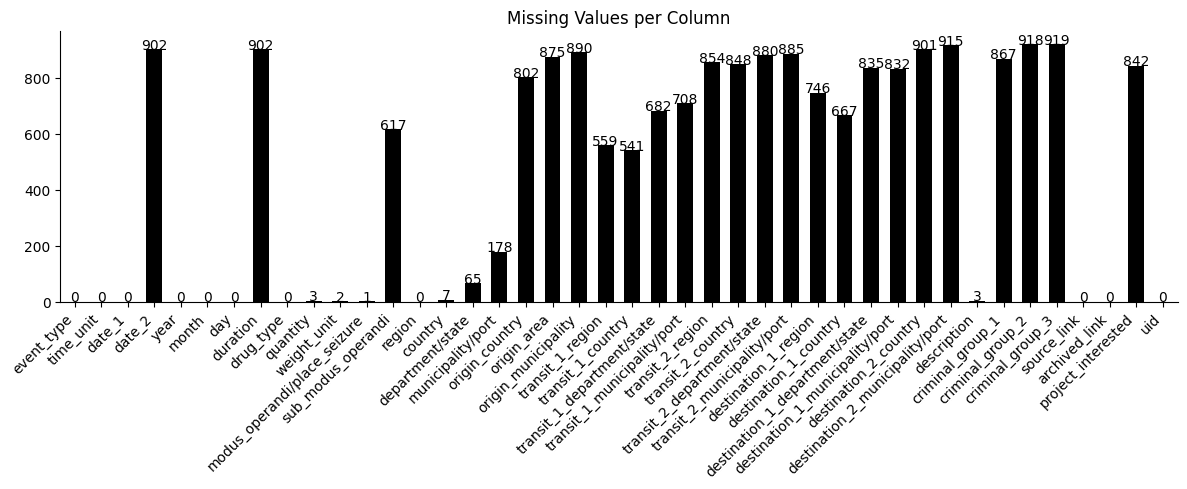

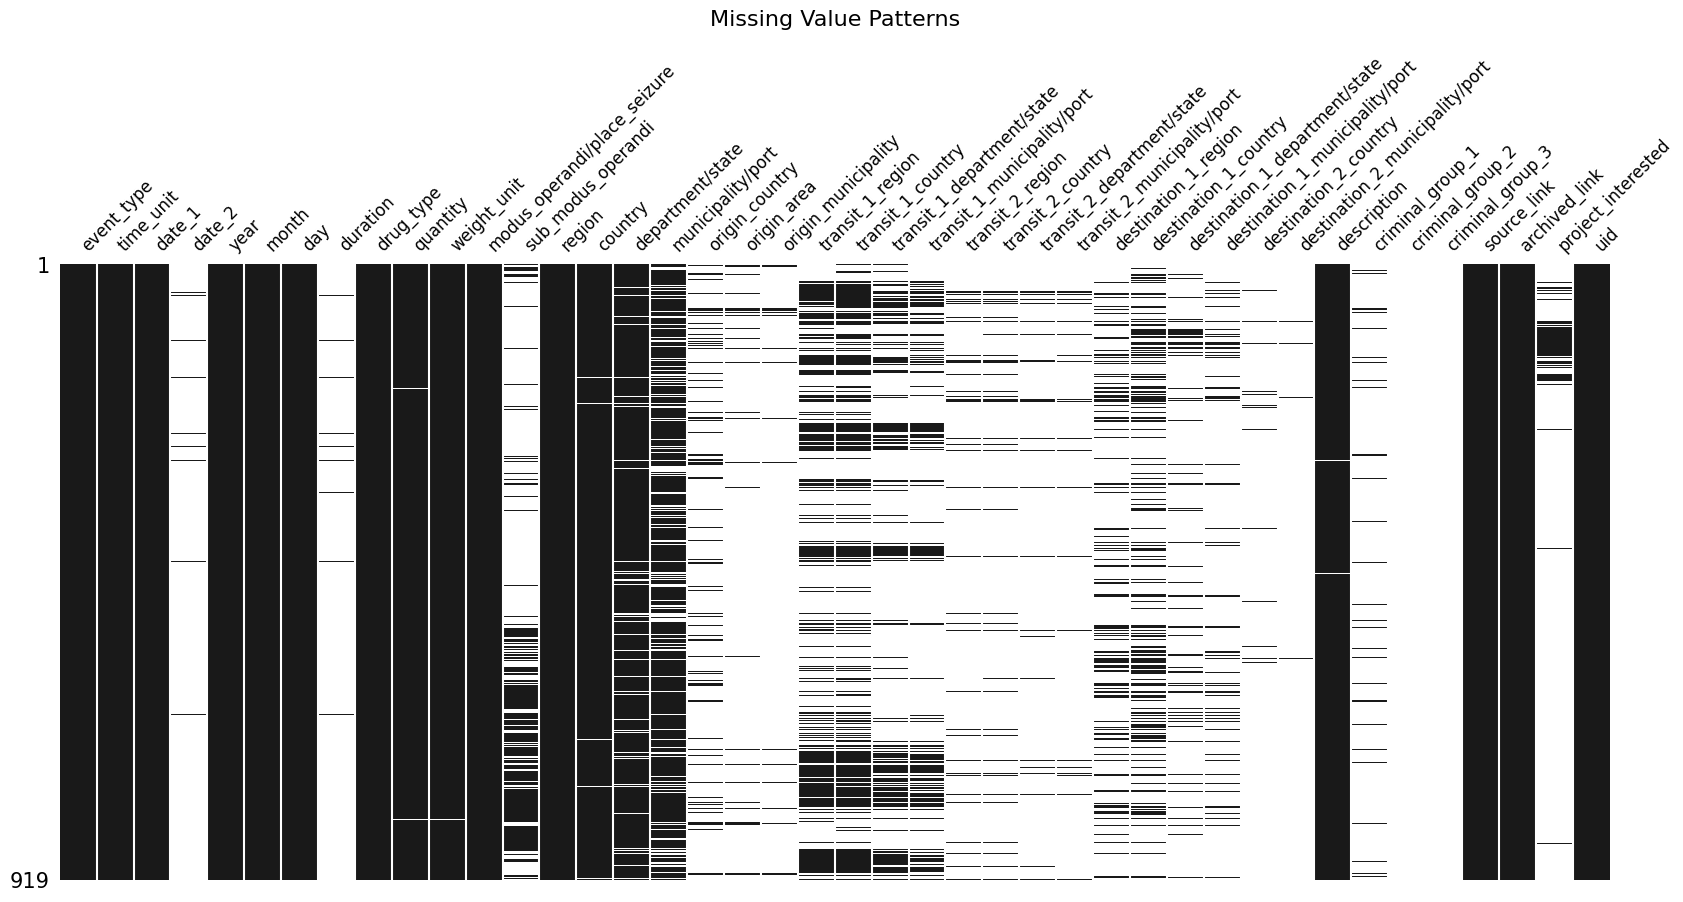

In [222]:
missing_values = df_b.isnull().sum()
print(f"Missing values per column:\n{missing_values}\n")

# Visualization 1: Bar Chart
plt.figure(figsize=(12, 5))
ax = missing_values.plot(kind='bar', color="#000000", width=0.6)
ax.grid(False)
for i in ax.patches:
    ax.text(i.get_x() + i.get_width()/2, i.get_height()+1, 
            f'{int(i.get_height())}', 
            ha='center', fontsize=10)
plt.xticks(rotation=45, ha='right')
sns.despine()
plt.title("Missing Values per Column")
plt.tight_layout()
plt.show()

# Visualization 2: Missingno Matrix
msno.matrix(
    df_b,
    figsize=(20, 8),
    color=(0.1, 0.1, 0.1),
    sparkline=False,
    fontsize=12,
    labels=True
)
plt.title("Missing Value Patterns", fontsize=16, pad=20)
plt.show()

### Indicators

###### Monthly seizures

/tmp/ipykernel_18138/512830838.py:83: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_text = drug_counts.sort_index(ascending=False).applymap(lambda x: f"{int(x):,}" if pd.notna(x) else "")
/tmp/ipykernel_18138/512830838.py:83: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_text = drug_counts.sort_index(ascending=False).applymap(lambda x: f"{int(x):,}" if pd.notna(x) else "")
/tmp/ipykernel_18138/512830838.py:83: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_text = drug_counts.sort_index(ascending=False).applymap(lambda x: f"{int(x):,}" if pd.notna(x) else "")
/tmp/ipykernel_18138/512830838.py:83: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_text = drug_counts.sort_index(ascending=False).applymap(lambda x: f"{int(x):,}" if pd.notna(x) else "")
/tmp/ipykernel_18138/512830838.py:83: FutureWarning: DataFrame.applymap 

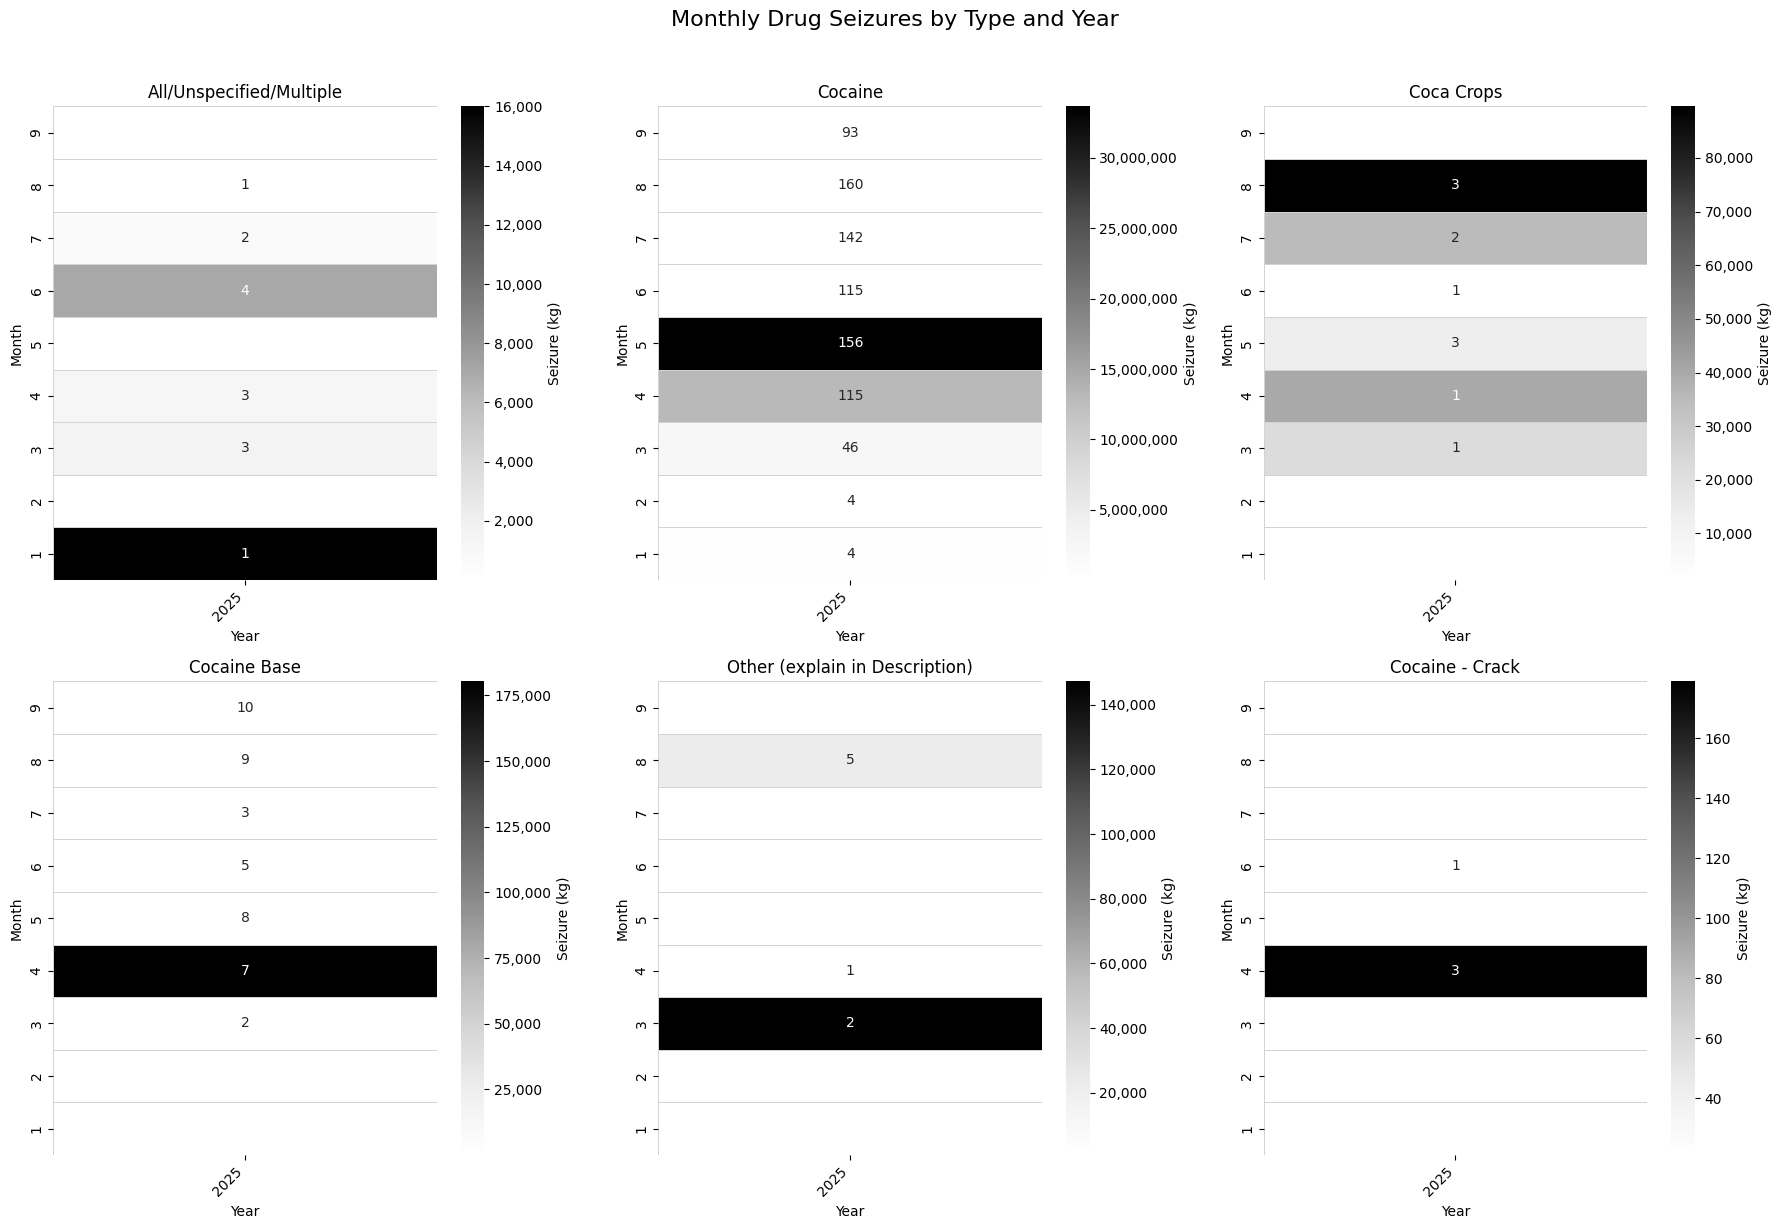

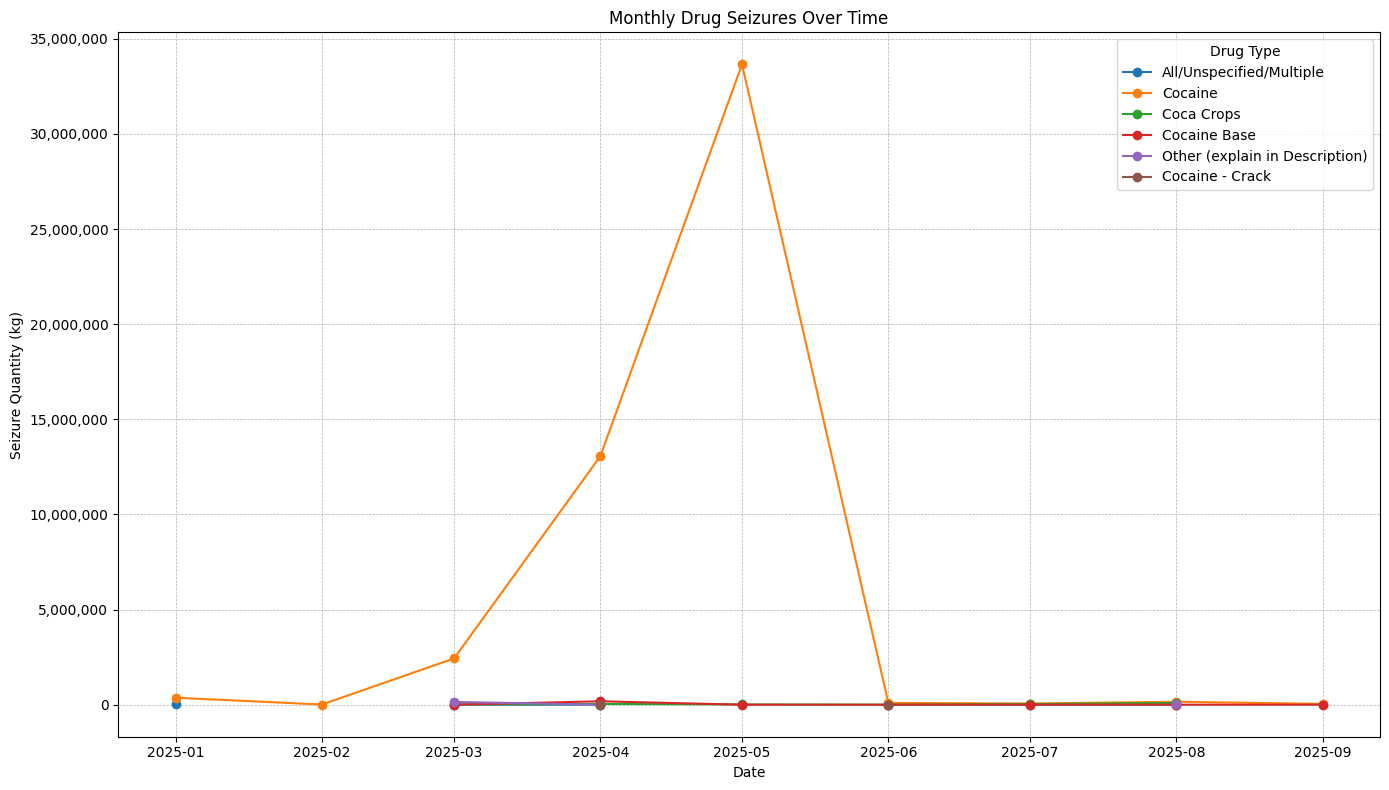

In [223]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from matplotlib.ticker import FuncFormatter
import numpy as np

# Clean the data - remove rows where drug_type is None/NaN
df_b = df_b.dropna(subset=['drug_type'])

# Convert and clean seizure data - using quantity and weight_unit instead of seizure_kg
# Assuming weight_unit is consistent within records and we can convert to kg
df_b['seizure_kg'] = pd.to_numeric(df_b['quantity'], errors='coerce')

# Handle weight_unit conversion if needed (example conversion factors)
weight_unit_conversion = {
    'kg': 1,
    'g': 0.001,
    'mg': 0.000001,
    'lb': 0.453592,
    'oz': 0.0283495
}

# Convert to kg based on weight_unit
if 'weight_unit' in df_b.columns:
    df_b['conversion_factor'] = df_b['weight_unit'].map(weight_unit_conversion).fillna(1)
    df_b['seizure_kg'] = df_b['seizure_kg'] * df_b['conversion_factor']
else:
    # If weight_unit doesn't exist, assume kg
    df_b['seizure_kg'] = df_b['seizure_kg']

# Create pivot tables grouped by drug_type
pivot_data = df_b.groupby(['year', 'month', 'drug_type']).agg(
    seizure_kg=('seizure_kg', 'sum'),
    event_count=('seizure_kg', 'count')
).unstack(level=[0, 2])  # Unstack both year and drug_type

# Extract components
seizure_kg = pivot_data['seizure_kg']
event_counts = pivot_data['event_count']

# Fill NaN values with 0
seizure_kg_filled = seizure_kg.fillna(0)

# Get unique drug types from the pivot table columns, not the original dataframe
if isinstance(seizure_kg.columns, pd.MultiIndex):
    drug_types = seizure_kg.columns.get_level_values(1).unique()
else:
    drug_types = seizure_kg.columns.unique()

# Calculate grid dimensions
n_drugs = len(drug_types)
n_cols = 3  # You can adjust this based on your preference
n_rows = math.ceil(n_drugs / n_cols)

# Create figure for grid layout
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6*n_rows))
fig.suptitle("Monthly Drug Seizures by Type and Year", y=1.02, fontsize=16)

# Flatten axes array for easy iteration
if n_rows > 1:
    axes = axes.flatten()
else:
    axes = [axes] if n_cols == 1 else axes

# Function to format numbers with commas
def format_with_commas(x, pos):
    return f"{x:,.0f}"

# Create formatter
comma_formatter = FuncFormatter(format_with_commas)

# Plot heatmap for each drug type in the grid
for i, drug in enumerate(drug_types):
    ax = axes[i]
    
    try:
        # Filter data for current drug type
        drug_kg = seizure_kg.xs(drug, level=1, axis=1)
        drug_counts = event_counts.xs(drug, level=1, axis=1)
        
        # Create annotation text with commas
        annot_text = drug_counts.sort_index(ascending=False).applymap(lambda x: f"{int(x):,}" if pd.notna(x) else "")
        
        heatmap = sns.heatmap(
            drug_kg.sort_index(ascending=False),
            cmap="Greys",
            annot=annot_text,
            fmt='',  # Empty string since we pre-formatted
            cbar_kws={'label': f'Seizure (kg)', 'format': comma_formatter},
            linewidths=0.5,
            linecolor='lightgray',
            ax=ax
        )
        
        # Format colorbar ticks with commas
        if heatmap.collections[0].colorbar is not None:
            heatmap.collections[0].colorbar.ax.yaxis.set_major_formatter(comma_formatter)
        
        ax.set_title(drug)
        ax.set_ylabel("Month")
        ax.set_xlabel("Year")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        
    except KeyError:
        print(f"Warning: Drug type '{drug}' not found in pivot data. Skipping...")
        ax.axis('off')
        continue

# Hide any empty subplots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# Line graph version with comma formatting
plt.figure(figsize=(14,8))

# Clean the data for line graph - drop rows with missing year or month
df_b_clean = df_b.dropna(subset=['year', 'month']).copy()

# Convert year and month to integers safely
df_b_clean['year'] = pd.to_numeric(df_b_clean['year'], errors='coerce')
df_b_clean['month'] = pd.to_numeric(df_b_clean['month'], errors='coerce')

# Drop rows where year or month couldn't be converted to numeric
df_b_clean = df_b_clean.dropna(subset=['year', 'month'])

# Convert to integers
df_b_clean['year'] = df_b_clean['year'].astype(int)
df_b_clean['month'] = df_b_clean['month'].astype(int)

# Create date column for proper time series plotting
df_b_clean['date'] = pd.to_datetime(
    df_b_clean['year'].astype(str) + '-' + 
    df_b_clean['month'].astype(str) + '-01',
    errors='coerce'
)

# Drop any rows where date conversion failed
df_b_clean = df_b_clean.dropna(subset=['date'])

# Group by date and drug type using the cleaned data
line_data = df_b_clean.groupby(['date', 'drug_type'])['seizure_kg'].sum().unstack()

# Plot each drug type that exists in line_data
for drug in drug_types:
    if drug in line_data.columns:
        plt.plot(line_data.index, line_data[drug], marker='o', label=drug)

plt.title("Monthly Drug Seizures Over Time")
plt.ylabel("Seizure Quantity (kg)")
plt.xlabel("Date")
plt.legend(title="Drug Type")
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Format y-axis with commas
plt.gca().yaxis.set_major_formatter(FuncFormatter(format_with_commas))

plt.tight_layout()
plt.show()

###### Routes

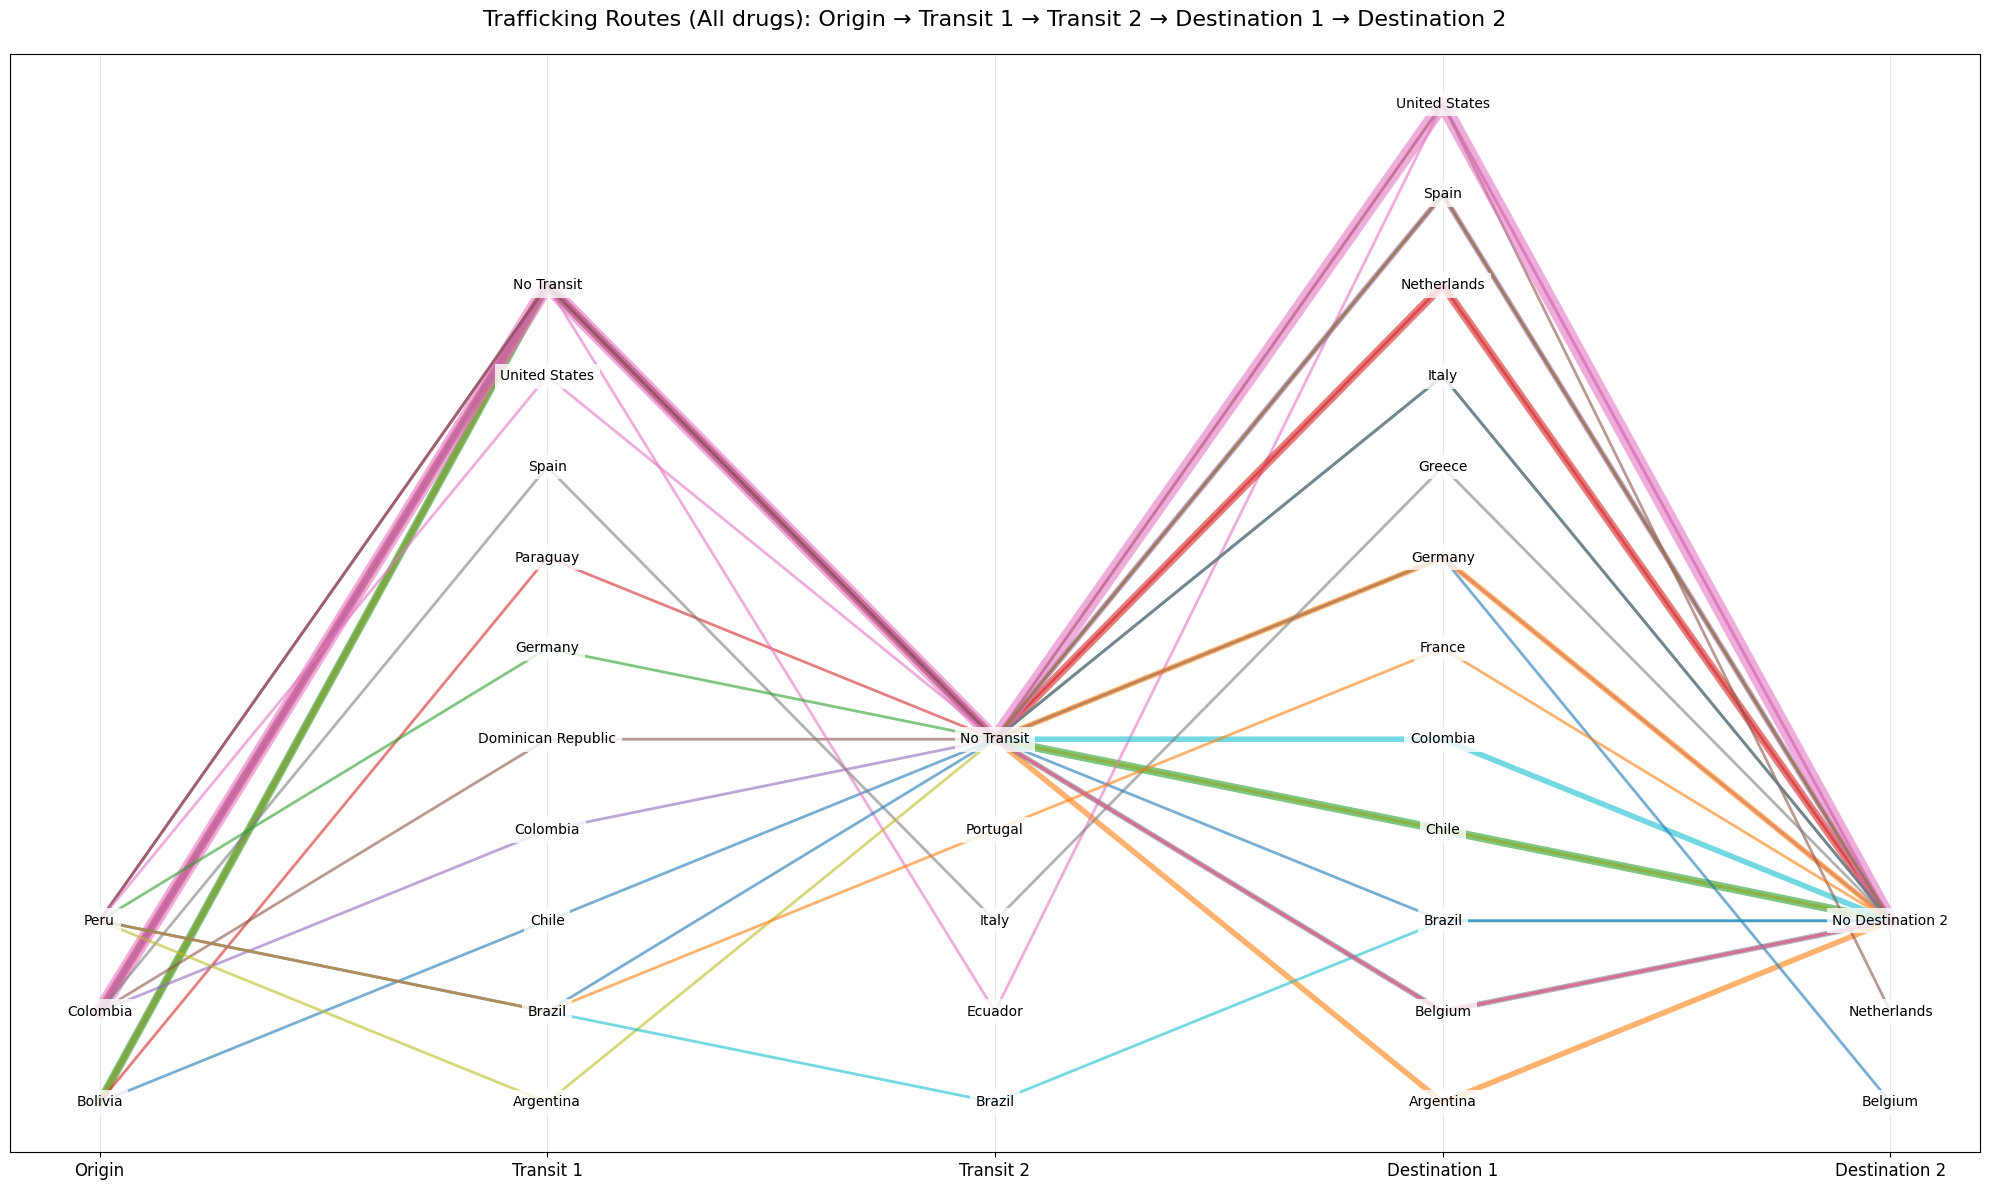

In [224]:
import matplotlib.pyplot as plt

def plot_parallel_sets(df_b): 
    # Define the column names
    columns = ['origin_country', 'transit_1_country', 'transit_2_country', 
         'destination_1_country', 'destination_2_country']
    
    # Copy and fill missing values
    df_b = df_b[columns].copy()
    df_b[columns[1]] = df_b[columns[1]].fillna('No Transit')
    df_b[columns[2]] = df_b[columns[2]].fillna('No Transit')
    df_b[columns[4]] = df_b[columns[4]].fillna('No Destination 2')
    
    # Filter incomplete rows
    df_b.dropna(subset=[columns[0], columns[3]], inplace=True)
    if df_b.empty:
        print("Warning: No data with both origin and destination information")
        return
    
    # Count path frequencies
    path_counts = df_b.groupby(columns).size().reset_index(name='count')
    
    # Prepare the plot
    plt.figure(figsize=(20, 12))

    # Map each category to a y-position (starting at 1)
    categories = {}
    for col in columns:
        values = df_b[col].unique()
        sorted_vals = sorted([v for v in values if "No" not in v]) + sorted([v for v in values if "No" in v])
        categories[col] = {val: idx + 1 for idx, val in enumerate(sorted_vals)}
    
    # Plot each path
    for _, row in path_counts.iterrows():
        y_values = [categories[col][row[col]] for col in columns]
        plt.plot(range(len(columns)), y_values, linewidth=row['count'] * 2, alpha=0.6)

    # X-axis: step names
    plt.xticks(range(len(columns)), ['Origin', 'Transit 1', 'Transit 2', 'Destination 1', 'Destination 2'], fontsize=12)
    
    # Y-axis: remove default numbers
    plt.yticks([])
    
    # Add node labels
    for i, col in enumerate(columns):
        for val, y in categories[col].items():
            plt.text(i, y, val, ha='center', va='center',
                     bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'), fontsize=10)
    
    # Final touches
    plt.title("Trafficking Routes (All drugs): Origin → Transit 1 → Transit 2 → Destination 1 → Destination 2", 
              fontsize=16, pad=20)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_parallel_sets(df_b)

###### Modus operandi

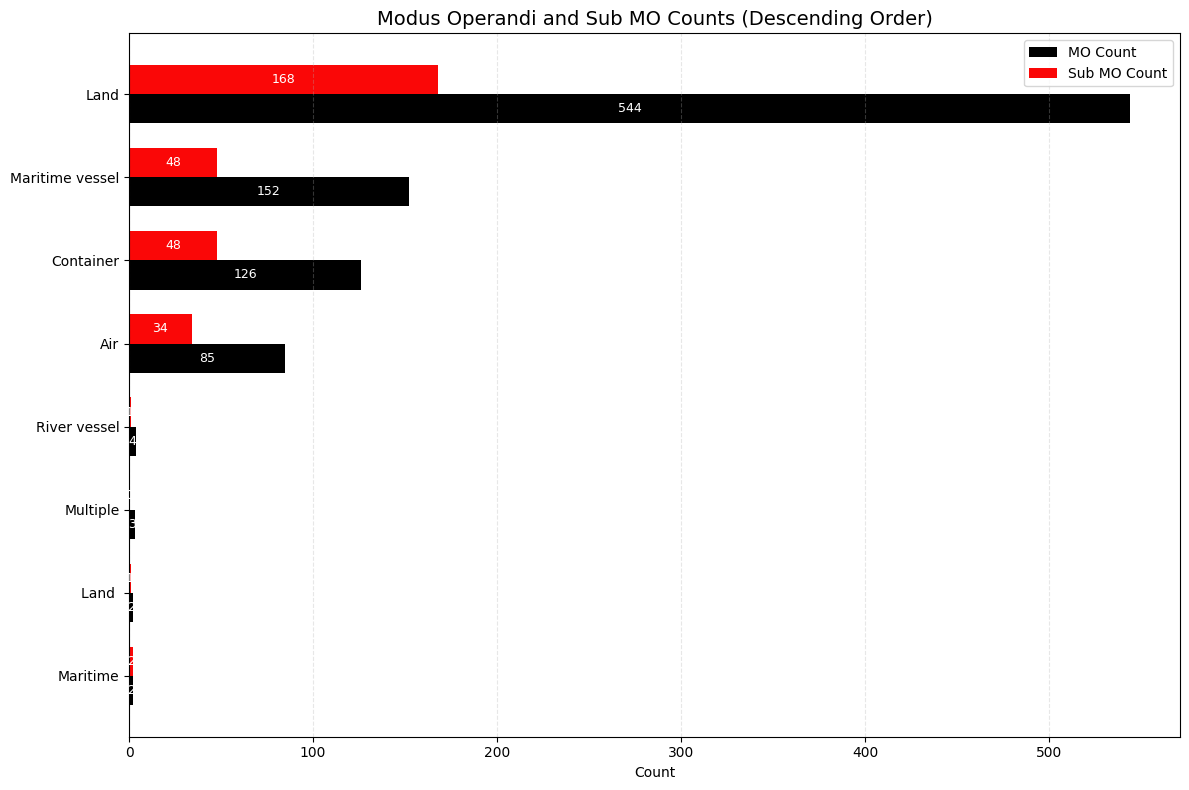

In [225]:
import numpy as np
import matplotlib.pyplot as plt

# Group counts and sort 
mo = df_b['modus_operandi/place_seizure'].value_counts().sort_values(ascending=True)
sub_mo = df_b.groupby('modus_operandi/place_seizure')['sub_modus_operandi'].count().reindex(mo.index)

# Plot horizontal bars
labels = mo.index
y = np.arange(len(labels))
h = 0.35

fig, ax = plt.subplots(figsize=(12, 8))
b1 = ax.barh(y - h/2, mo, h, label='MO Count', color="#000000")
b2 = ax.barh(y + h/2, sub_mo, h, label='Sub MO Count', color="#FA0707")

# Label bars
for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_width()/2, bar.get_y() + bar.get_height()/2,
                str(int(bar.get_width())), ha='center', va='center', color='white', fontsize=9)

# Style
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_title('Modus Operandi and Sub MO Counts (Descending Order)', fontsize=14)
ax.legend()
ax.set_xlabel('Count')
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show()

In [226]:
end_time = time.time()
end_readable = time.ctime(end_time)
execution_time = (end_time - start_time)/60


print(f"Start: {formatted_start_time}")
print(f"End: {end_readable}")
print(f"Execution time: {execution_time:.2f} minutes")

print("="*80)

Start: Tue Sep 30 11:39:01 2025
End: Tue Sep 30 11:41:06 2025
Execution time: 2.08 minutes
